# Clustering

In [1]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
import umap
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_goals = pd.read_csv('/content/goals_cleaned.csv')

features = ['Goals', 'Assists', 'Goals_Assists', 'Non_Penalty_Goals', 'Penalties_Made',
            'Penalties_Attempted', 'Penalties_Missed']

for feature in features:
    df_goals[f'{feature}_per90'] = df_goals[feature] / df_goals['90s']

goals_features = df_goals[[f'{feature}_per90' for feature in features]]

goals_features = goals_features.replace([np.inf, -np.inf], np.nan).fillna(0)

scaler = StandardScaler()
goals_features_scaled = scaler.fit_transform(goals_features)

print("Prepared Features (first 5 rows):")
print(pd.DataFrame(goals_features_scaled, columns=[f'{feature}_per90' for feature in features]).head())

Prepared Features (first 5 rows):
   Goals_per90  Assists_per90  Goals_Assists_per90  Non_Penalty_Goals_per90  \
0     3.264887      -0.571762             2.465333                 2.643309   
1     2.358066       2.993983             3.277671                 1.491154   
2     3.033388      -0.804906             2.170264                 3.015694   
3     3.368887       1.700976             3.550558                 2.085504   
4     3.185324       1.353394             3.245087                 2.914830   

   Penalties_Made_per90  Penalties_Attempted_per90  Penalties_Missed_per90  
0              3.489054                   3.820804                2.696865  
1              3.916419                   3.215873               -0.397508  
2              1.371354                   1.574060                1.290807  
3              5.745113                   4.775611               -0.397508  
4              2.281677                   2.412372                1.488308  


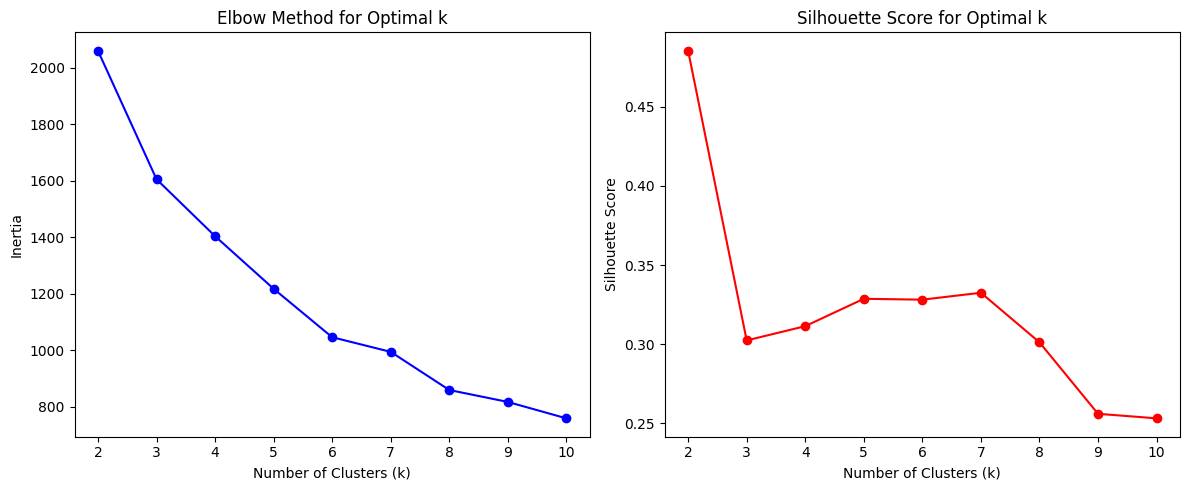

In [3]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

inertia = []
silhouette_scores = []
K = range(2, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(goals_features_scaled)
    inertia.append(kmeans.inertia_)
    if k > 1:
        score = silhouette_score(goals_features_scaled, kmeans.labels_)
        silhouette_scores.append(score)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(K, inertia, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')

plt.subplot(1, 2, 2)
plt.plot(range(2, 11), silhouette_scores, 'ro-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Optimal k')
plt.tight_layout()
plt.show()



In [4]:
optimal_k = 7
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
df_goals['Goals_Cluster'] = kmeans.fit_predict(goals_features_scaled)

print("Cluster Counts:")
print(df_goals['Goals_Cluster'].value_counts())
print("\nSample Players in Each Cluster:")
for cluster in range(optimal_k):
    print(f"\nCluster {cluster}:")
    print(df_goals[df_goals['Goals_Cluster'] == cluster][['Player', 'Goals_per90', 'Assists_per90', 'Goals_Assists_per90']].head(10))

Cluster Counts:
Goals_Cluster
1    183
5    116
0     63
6     44
3     28
4     23
2      3
Name: count, dtype: int64

Sample Players in Each Cluster:

Cluster 0:
             Player  Goals_per90  Assists_per90  Goals_Assists_per90
20         Raphinha     0.571429       0.285714             0.857143
24    Ollie Watkins     0.553633       0.276817             0.830450
37  Bradley Barcola     0.578512       0.413223             0.991736
42     Jarrod Bowen     0.393939       0.242424             0.636364
52   Evann Guessand     0.421053       0.280702             0.701754
53    Michael Olise     0.463320       0.579151             1.042471
60       Leroy Sané     0.604396       0.274725             0.879121
66  Andrej Kramarić     0.358306       0.260586             0.618893
75    Gaëtan Perrin     0.334448       0.367893             0.702341
79   Mohamed Amoura     0.364964       0.328467             0.693431

Cluster 1:
                 Player  Goals_per90  Assists_per90  Goals_Assist

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


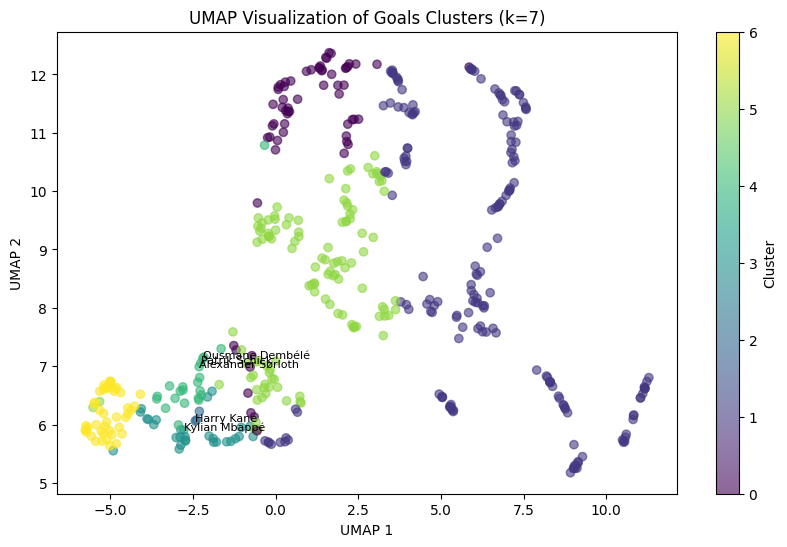

In [5]:
reducer = umap.UMAP(n_components=2, random_state=42)
goals_umap = reducer.fit_transform(goals_features_scaled)

df_umap = pd.DataFrame(goals_umap, columns=['UMAP1', 'UMAP2'])
df_umap['Cluster'] = df_goals['Goals_Cluster']
df_umap['Player'] = df_goals['Player']

plt.figure(figsize=(10, 6))
scatter = plt.scatter(df_umap['UMAP1'], df_umap['UMAP2'], c=df_umap['Cluster'], cmap='viridis', alpha=0.6)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.title('UMAP Visualization of Goals Clusters (k=7)')

top_players = df_goals.sort_values('Goals_per90', ascending=False).head(5)['Player']
for i, player in enumerate(df_umap['Player']):
    if player in top_players.values:
        plt.annotate(player, (df_umap['UMAP1'][i], df_umap['UMAP2'][i]), fontsize=8)

plt.show()

In [6]:
cluster_summary = df_goals.groupby('Goals_Cluster')[[f'{feature}_per90' for feature in features]].mean()
print("Cluster Summary (Average Stats per 90):")
print(cluster_summary)

for cluster in range(optimal_k):
    avg_goals = cluster_summary.loc[cluster, 'Goals_per90']
    avg_assists = cluster_summary.loc[cluster, 'Assists_per90']
    avg_npg = cluster_summary.loc[cluster, 'Non_Penalty_Goals_per90']
    avg_pen = cluster_summary.loc[cluster, 'Penalties_Made_per90']
    print(f"Cluster {cluster}: Avg Goals per 90 = {avg_goals:.2f}, Avg Assists per 90 = {avg_assists:.2f}, "
          f"Avg Non-Penalty Goals per 90 = {avg_npg:.2f}, Avg Penalties Made per 90 = {avg_pen:.2f}")
    if avg_goals > 0.7 and avg_assists > 0.25:
        print("   Suggested Label: 'Elite Two-Level Threat' (High goals and assists)")
    elif avg_goals > 0.5 and avg_npg > avg_pen * 2:
        print("   Suggested Label: 'Non-Penalty Specialist' (High goals, mostly non-penalty)")
    elif avg_goals > 0.4 and avg_pen > avg_npg / 2:
        print("   Suggested Label: 'Penalty-Dependent Striker' (Relies on penalties)")
    elif avg_goals > 0.3 and avg_assists > 0.15 and avg_goals > avg_assists:
        print("   Suggested Label: 'Balanced Forward' (Balanced, goal-focused)")
    elif avg_assists > 0.25 and avg_assists > avg_goals:
        print("   Suggested Label: 'Creative Forward' (High assists, lower goals)")
    elif avg_goals > 0.2 and avg_assists > 0.15:
        print("   Suggested Label: 'Moderate Contributor' (Moderate goals and assists)")
    else:
        print("   Suggested Label: 'Low Contributor' (Low goals and assists)")

df_goals.to_csv('/content/goals_with_clusters.csv', index=False)
print("\nSaved goals dataset with clusters to '/content/goals_with_clusters.csv'")

Cluster Summary (Average Stats per 90):
               Goals_per90  Assists_per90  Goals_Assists_per90  \
Goals_Cluster                                                    
0                 0.285413       0.324135             0.609548   
1                 0.121007       0.108212             0.229219   
2                 0.890377       0.328763             1.219140   
3                 0.476223       0.187309             0.663532   
4                 0.834306       0.157776             0.992082   
5                 0.387058       0.113786             0.500843   
6                 0.284695       0.181738             0.466432   

               Non_Penalty_Goals_per90  Penalties_Made_per90  \
Goals_Cluster                                                  
0                             0.275062              0.010350   
1                             0.117157              0.003850   
2                             0.613836              0.276541   
3                             0.305330       

In [7]:
df_xg = pd.read_csv('/content/xg_stats_cleaned.csv')
features = ['xG', 'G-xG', 'np:G-xG', 'A-xAG', 'xA']

xg_features = df_xg[features]

scaler = StandardScaler()
xg_features_scaled = scaler.fit_transform(xg_features)

print("Prepared Features (first 5 rows):")
print(pd.DataFrame(xg_features_scaled, columns=features).head())

Prepared Features (first 5 rows):
         xG      G-xG   np:G-xG     A-xAG        xA
0  4.750612 -0.154001 -0.112591 -0.244160 -0.420173
1  4.480621  2.323276  2.543398 -3.120641  2.034457
2  4.323127  1.703956  0.772739  2.436198  4.989104
3  3.760646 -0.916240 -0.899550  0.017338  0.307125
4  3.603152 -0.106361 -0.014221 -0.048036 -0.101980


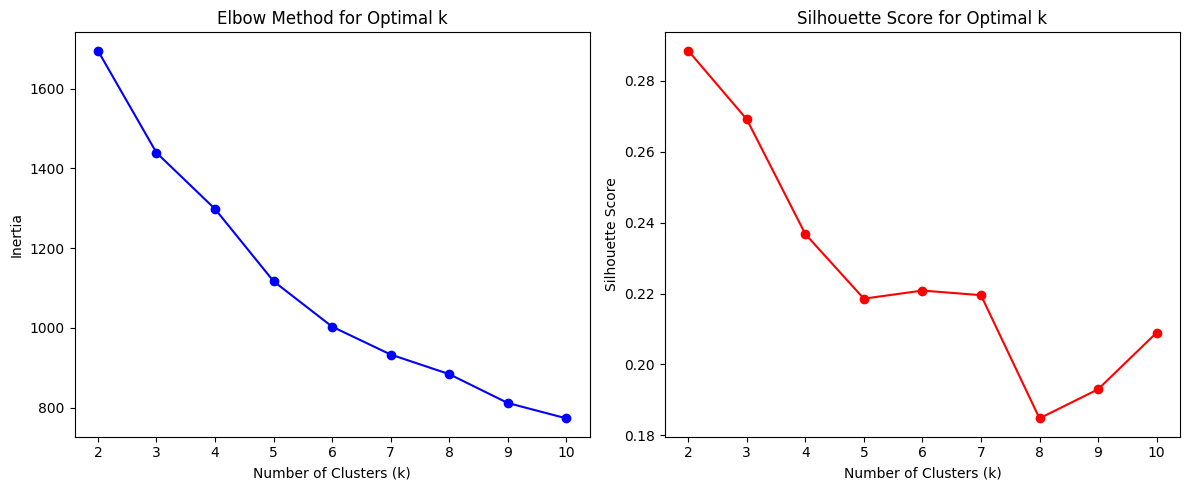

Cluster Counts:
xG_Cluster
1    157
4    142
0     68
2     52
3     41
Name: count, dtype: int64


In [8]:
inertia = []
silhouette_scores = []
K = range(2, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(xg_features_scaled)
    inertia.append(kmeans.inertia_)
    if k > 1:
        score = silhouette_score(xg_features_scaled, kmeans.labels_)
        silhouette_scores.append(score)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(K, inertia, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')

plt.subplot(1, 2, 2)
plt.plot(range(2, 11), silhouette_scores, 'ro-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Optimal k')
plt.tight_layout()
plt.show()

optimal_k = 5
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
df_xg['xG_Cluster'] = kmeans.fit_predict(xg_features_scaled)

print("Cluster Counts:")
print(df_xg['xG_Cluster'].value_counts())

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


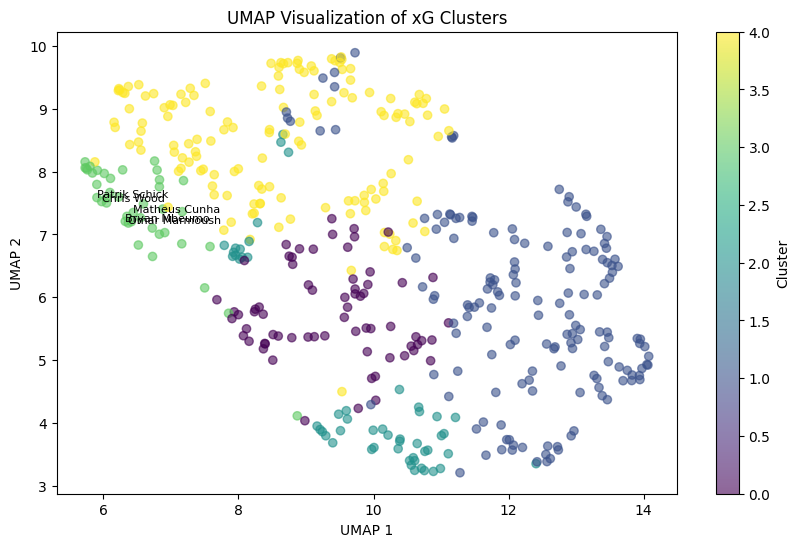

In [9]:
reducer = umap.UMAP(n_components=2, random_state=42)
xg_umap = reducer.fit_transform(xg_features_scaled)

df_umap = pd.DataFrame(xg_umap, columns=['UMAP1', 'UMAP2'])
df_umap['Cluster'] = df_xg['xG_Cluster']
df_umap['Player'] = df_xg['Player']

plt.figure(figsize=(10, 6))
scatter = plt.scatter(df_umap['UMAP1'], df_umap['UMAP2'], c=df_umap['Cluster'], cmap='viridis', alpha=0.6)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.title('UMAP Visualization of xG Clusters')

top_players = df_xg.sort_values('G-xG', ascending=False).head(5)['Player']
for i, player in enumerate(df_umap['Player']):
    if player in top_players.values:
        plt.annotate(player, (df_umap['UMAP1'][i], df_umap['UMAP2'][i]), fontsize=8)

plt.show()

In [10]:
cluster_summary = df_xg.groupby('xG_Cluster')[features].mean()
print("Cluster Summary (Average Stats):")
print(cluster_summary)

for cluster in range(5):
    avg_xg = cluster_summary.loc[cluster, 'xG']
    avg_g_xg = cluster_summary.loc[cluster, 'G-xG']
    avg_np_g_xg = cluster_summary.loc[cluster, 'np:G-xG']
    avg_a_xag = cluster_summary.loc[cluster, 'A-xAG']
    avg_xa = cluster_summary.loc[cluster, 'xA']
    print(f"Cluster {cluster}: Avg xG = {avg_xg:.2f}, Avg G-xG = {avg_g_xg:.2f}, Avg np:G-xG = {avg_np_g_xg:.2f}, "
          f"Avg A-xAG = {avg_a_xag:.2f}, Avg xA = {avg_xa:.2f}")
    if avg_g_xg > 2 and avg_np_g_xg > 2:
        print("   Suggested Label: 'Efficient Finisher' (Overperforms xG significantly)")
    elif avg_g_xg < -1.5 and avg_np_g_xg < -1.5:
        print("   Suggested Label: 'Wasteful Striker' (Underperforms xG significantly)")
    elif avg_xa > 4 and avg_a_xag > 1:
        print("   Suggested Label: 'Versatile Playmaker' (High xA, teammates convert well)")
    elif avg_g_xg > 0.5 and avg_a_xag < -0.5:
        print("   Suggested Label: 'Unrecognized Finisher' (Good goals, underutilized assists)")
    elif avg_g_xg < -0.5 and avg_np_g_xg < -0.5:
        print("   Suggested Label: 'Inefficient Striker' (Underperforms xG moderately)")
    else:
        print("   Suggested Label: 'Balanced Performer' (Moderate realization and creativity)")

df_xg.to_csv('/content/xg_with_clusters.csv', index=False)
print("\nSaved xG dataset with clusters to '/content/xg_with_clusters.csv'")

Cluster Summary (Average Stats):
                   xG      G-xG   np:G-xG     A-xAG        xA
xG_Cluster                                                   
0            6.860294  0.433824  0.463235  2.347059  4.285294
1            3.581529 -1.180255 -1.140127 -0.052866  1.836306
2           12.246154 -1.861538 -1.813462 -0.151923  4.940385
3           10.843902  4.448780  4.268293  0.056098  4.748780
4            4.528873  1.217606  1.211972 -0.788028  3.182394
Cluster 0: Avg xG = 6.86, Avg G-xG = 0.43, Avg np:G-xG = 0.46, Avg A-xAG = 2.35, Avg xA = 4.29
   Suggested Label: 'Versatile Playmaker' (High xA, teammates convert well)
Cluster 1: Avg xG = 3.58, Avg G-xG = -1.18, Avg np:G-xG = -1.14, Avg A-xAG = -0.05, Avg xA = 1.84
   Suggested Label: 'Inefficient Striker' (Underperforms xG moderately)
Cluster 2: Avg xG = 12.25, Avg G-xG = -1.86, Avg np:G-xG = -1.81, Avg A-xAG = -0.15, Avg xA = 4.94
   Suggested Label: 'Wasteful Striker' (Underperforms xG significantly)
Cluster 3: Avg xG = 1

In [11]:
for cluster in range(optimal_k):
    print(f"\nCluster {cluster}:")
    print(df_xg[df_xg['xG_Cluster'] == cluster][['Player', 'xG', 'G-xG', 'np:G-xG', 'A-xAG', 'xA']].head(10))


Cluster 0:
                Player    xG  G-xG  np:G-xG  A-xAG   xA
12        Ante Budimir  18.3   2.7      0.7    2.3  1.7
20       Ollie Watkins  15.3   0.7      0.2    4.7  3.3
33       Romelu Lukaku  13.0   1.0      1.2    6.0  4.0
42     Nikola Krstović  12.1  -1.1     -0.7    2.1  2.9
43   Christian Pulisic  12.0  -1.0     -0.9    2.6  6.4
45        Amine Gouiri  12.0   1.0      1.0    1.0  4.0
48     Andrej Kramarić  11.8  -0.8     -1.5    3.7  4.3
51          Javi Puado  11.6   0.4     -0.7    1.0  3.0
56     Brennan Johnson  10.4   0.6      0.6    0.7  2.3
60  Georges Mikautadze  10.3   0.7      1.0    1.7  4.3

Cluster 1:
                  Player   xG  G-xG  np:G-xG  A-xAG   xA
79           Kai Havertz  9.5  -0.5     -0.5    0.6  2.4
100         M'Bala Nzola  8.6  -2.6     -2.6   -0.3  1.3
105                 Beto  8.2  -0.2     -0.2   -1.2  1.2
112           Diogo Jota  7.9  -1.9     -1.9    1.2  1.8
118          Lucas Höler  7.7  -1.7     -0.9    1.1  2.9
126      Joel Pohj

In [12]:
df_shooting = pd.read_csv('/content/shots_cleaned.csv')

features = ['Shots_Total', 'Shots_on_Target', 'Shot_on_Target_Percentage',
            'Goals_per_Shot', 'Goals_per_Shot_on_Target', 'Average_Shot_Distance', 'Free_Kicks']

df_shooting['Shots_Total_per90'] = (df_shooting['Shots_Total'] / (df_shooting['Total_Minutes'] / 90))
df_shooting['Shots_on_Target_per90'] = (df_shooting['Shots_on_Target'] / (df_shooting['Total_Minutes'] / 90))
df_shooting['Free_Kicks_per90'] = (df_shooting['Free_Kicks'] / (df_shooting['Total_Minutes'] / 90))

df_shooting['Goals_per_Shot_on_Target'] = df_shooting['Goals_per_Shot_on_Target'].fillna(df_shooting['Goals_per_Shot_on_Target'].mean())

shooting_features = df_shooting[['Shots_Total_per90', 'Shots_on_Target_per90', 'Shot_on_Target_Percentage',
                                'Goals_per_Shot', 'Goals_per_Shot_on_Target', 'Average_Shot_Distance', 'Free_Kicks_per90']]

scaler = StandardScaler()
shooting_features_scaled = scaler.fit_transform(shooting_features)

print("Prepared Features (first 5 rows):")
print(pd.DataFrame(shooting_features_scaled, columns=['Shots_Total_per90', 'Shots_on_Target_per90', 'Shot_on_Target_Percentage',
                                                     'Goals_per_Shot', 'Goals_per_Shot_on_Target', 'Average_Shot_Distance', 'Free_Kicks_per90']).head())

Prepared Features (first 5 rows):
   Shots_Total_per90  Shots_on_Target_per90  Shot_on_Target_Percentage  \
0           1.813641               2.343963                   1.135998   
1          -0.074932               0.765127                   1.673469   
2          -0.224794               0.446504                   1.353053   
3          -0.346244               0.895144                   2.583035   
4           1.560040               1.589182                   0.536511   

   Goals_per_Shot  Goals_per_Shot_on_Target  Average_Shot_Distance  \
0        2.652684                  2.007358              -1.511236   
1        2.345213                  1.298492              -0.784289   
2        2.191478                  1.362934              -0.973928   
3        2.191478                  0.654069              -1.669268   
4        2.037742                  1.878473              -0.752683   

   Free_Kicks_per90  
0         -0.518458  
1         -0.518458  
2         -0.518458  
3         -0

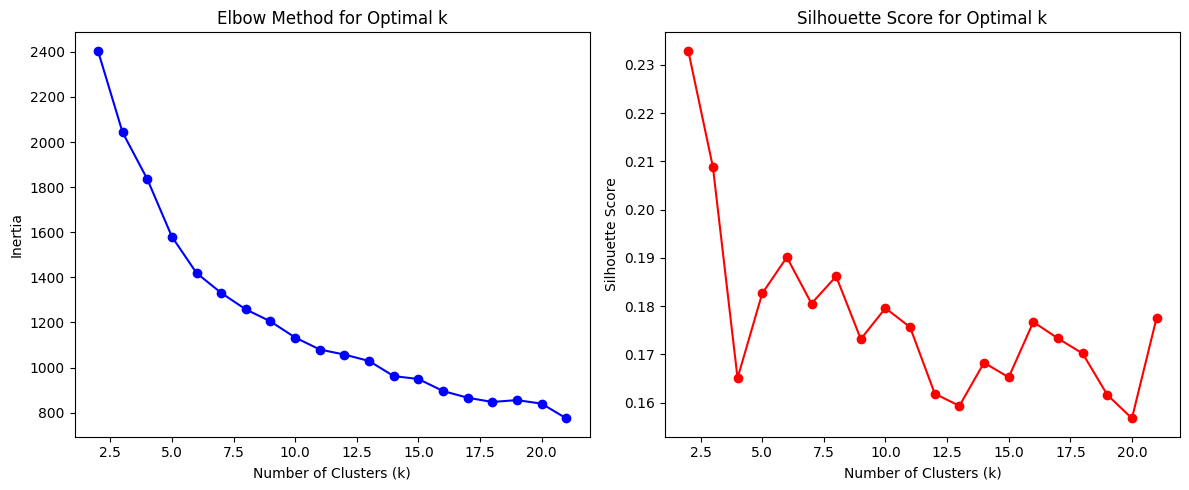

Cluster Counts:
Shooting_Cluster
0    126
1     78
2     74
4     74
3     72
5     39
Name: count, dtype: int64


In [13]:
inertia = []
silhouette_scores = []
K = range(2, 22)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(shooting_features_scaled)
    inertia.append(kmeans.inertia_)
    if k > 1:
        score = silhouette_score(shooting_features_scaled, kmeans.labels_)
        silhouette_scores.append(score)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(K, inertia, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')

plt.subplot(1, 2, 2)
plt.plot(range(2, 22), silhouette_scores, 'ro-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Optimal k')
plt.tight_layout()
plt.show()

optimal_k = 6
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
df_shooting['Shooting_Cluster'] = kmeans.fit_predict(shooting_features_scaled)

print("Cluster Counts:")
print(df_shooting['Shooting_Cluster'].value_counts())

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


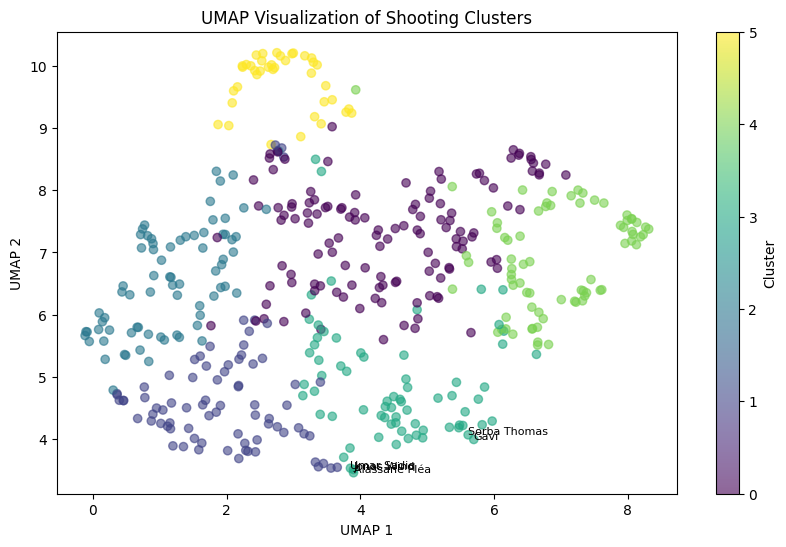

In [14]:
reducer = umap.UMAP(n_components=2, random_state=42)
shooting_umap = reducer.fit_transform(shooting_features_scaled)

df_umap = pd.DataFrame(shooting_umap, columns=['UMAP1', 'UMAP2'])
df_umap['Cluster'] = df_shooting['Shooting_Cluster']
df_umap['Player'] = df_shooting['Player']

plt.figure(figsize=(10, 6))
scatter = plt.scatter(df_umap['UMAP1'], df_umap['UMAP2'], c=df_umap['Cluster'], cmap='viridis', alpha=0.6)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.title('UMAP Visualization of Shooting Clusters')

top_players = df_shooting.sort_values('Goals_per_Shot_on_Target', ascending=False).head(5)['Player']
for i, player in enumerate(df_umap['Player']):
    if player in top_players.values:
        plt.annotate(player, (df_umap['UMAP1'][i], df_umap['UMAP2'][i]), fontsize=8)

plt.show()

In [15]:
cluster_summary = df_shooting.groupby('Shooting_Cluster')[['Shots_Total_per90', 'Shots_on_Target_per90', 'Shot_on_Target_Percentage',
                                                         'Goals_per_Shot', 'Goals_per_Shot_on_Target', 'Average_Shot_Distance', 'Free_Kicks_per90']].mean()
print("Cluster Summary (Average Stats per 90):")
print(cluster_summary)

for cluster in range(6):
    avg_shots_per90 = cluster_summary.loc[cluster, 'Shots_Total_per90']
    avg_sot_per90 = cluster_summary.loc[cluster, 'Shots_on_Target_per90']
    avg_sot_pct = cluster_summary.loc[cluster, 'Shot_on_Target_Percentage']
    avg_gps = cluster_summary.loc[cluster, 'Goals_per_Shot']
    avg_gpsot = cluster_summary.loc[cluster, 'Goals_per_Shot_on_Target']
    avg_distance = cluster_summary.loc[cluster, 'Average_Shot_Distance']
    avg_fk_per90 = cluster_summary.loc[cluster, 'Free_Kicks_per90']
    print(f"Cluster {cluster}: Avg Shots per 90 = {avg_shots_per90:.2f}, Avg Shots on Target per 90 = {avg_sot_per90:.2f}, "
          f"Avg Shot on Target % = {avg_sot_pct:.2f}, Avg Goals per Shot = {avg_gps:.2f}, "
          f"Avg Goals per Shot on Target = {avg_gpsot:.2f}, Avg Shot Distance = {avg_distance:.2f}, Avg Free Kicks per 90 = {avg_fk_per90:.2f}")
    if avg_gpsot > 0.4 and avg_sot_pct > 0.35:
        print("   Suggested Label: 'Clinical Finisher' (High finishing precision)")
    elif avg_shots_per90 > 3.0 and avg_gps < 0.15:
        print("   Suggested Label: 'High-Volume Shooter' (High shots, low efficiency)")
    elif avg_fk_per90 > 0.1 and avg_gps > 0.08:
        print("   Suggested Label: 'Set-Piece Threat' (Relies on free kicks)")
    elif avg_distance > 18.0 and avg_gps > 0.08:
        print("   Suggested Label: 'Long-Range Specialist' (Far shots, decent efficiency)")
    elif avg_distance > 18.0 and avg_gps < 0.05:
        print("   Suggested Label: 'Long-Range Inefficient Shooter' (Far shots, low efficiency)")
    elif avg_shots_per90 > 2.0 and avg_gpsot < 0.3:
        print("   Suggested Label: 'Moderate Volume Shooter' (Moderate shots, low precision)")
    elif avg_shots_per90 < 2.0 and avg_gpsot > 0.4:
        print("   Suggested Label: 'Low-Volume Precise Shooter' (Low shots, high precision)")
    else:
        print("   Suggested Label: 'Balanced Shooter' (Moderate stats)")

df_shooting.to_csv('/content/shooting_with_clusters.csv', index=False)
print("\nSaved Shooting dataset with clusters to '/content/shooting_with_clusters.csv'")

Cluster Summary (Average Stats per 90):
                  Shots_Total_per90  Shots_on_Target_per90  \
Shooting_Cluster                                             
0                          2.136734               0.797199   
1                          2.082444               0.939857   
2                          3.279310               1.297694   
3                          1.547435               0.488541   
4                          1.331728               0.336670   
5                          2.788171               0.968292   

                  Shot_on_Target_Percentage  Goals_per_Shot  \
Shooting_Cluster                                              
0                                  0.376738        0.086667   
1                                  0.455423        0.207821   
2                                  0.395541        0.138108   
3                                  0.316986        0.142917   
4                                  0.251054        0.042568   
5                     

In [16]:
df_passing = pd.read_csv('/content/passing_cleaned.csv')

df_passing['Key_Passes_per90'] = df_passing['Key_Passes'] / (df_passing['Total_Minutes'] / 90)
df_passing['Passes_into_Penalty_Area_per90'] = df_passing['Passes_into_Penalty_Area'] / (df_passing['Total_Minutes'] / 90)
df_passing['Crosses_into_Penalty_Area_per90'] = df_passing['Crosses_into_Penalty_Area'] / (df_passing['Total_Minutes'] / 90)
df_passing['Progressive_Passes_per90'] = df_passing['Progressive_Passes'] / (df_passing['Total_Minutes'] / 90)
df_passing['Cmp_Total_per90'] = df_passing['Cmp_Total'] / (df_passing['Total_Minutes'] / 90)
df_passing['Progressive_Distance_per90'] = df_passing['Progressive_Distance'] / (df_passing['Total_Minutes'] / 90)
df_passing['Effective_Completion_Rate'] = (df_passing['Cmp_Total'] / df_passing['Att_Total']) * (df_passing['Progressive_Passes'] / (df_passing['Cmp_Total'] + 1))
df_passing['Short_Medium_Long_Balance'] = (df_passing['Cmp_Short'] + df_passing['Cmp_Medium']) / (df_passing['Cmp_Long'] + 1)

passing_features = df_passing[['Key_Passes_per90', 'Passes_into_Penalty_Area_per90', 'Crosses_into_Penalty_Area_per90',
                              'Progressive_Passes_per90', 'Cmp_Total_per90', 'Progressive_Distance_per90',
                              'Effective_Completion_Rate', 'Short_Medium_Long_Balance']]

scaler = StandardScaler()
passing_features_scaled = scaler.fit_transform(passing_features)

print("Prepared Features (first 5 rows):")
print(pd.DataFrame(passing_features_scaled, columns=['Key_Passes_per90', 'Passes_into_Penalty_Area_per90',
                                                    'Crosses_into_Penalty_Area_per90', 'Progressive_Passes_per90',
                                                    'Cmp_Total_per90', 'Progressive_Distance_per90',
                                                    'Effective_Completion_Rate', 'Short_Medium_Long_Balance']).head())

Prepared Features (first 5 rows):
   Key_Passes_per90  Passes_into_Penalty_Area_per90  \
0          0.795479                        0.466551   
1          0.093683                        0.319615   
2         -0.144156                        0.242567   
3          1.455118                        2.186919   
4          3.608480                        4.873093   

   Crosses_into_Penalty_Area_per90  Progressive_Passes_per90  Cmp_Total_per90  \
0                        -0.074996                  1.011957         2.895393   
1                         0.445226                  0.989191         3.633703   
2                        -0.651317                  2.315735         2.027091   
3                         0.208260                  2.428834         2.909416   
4                         0.993460                  2.638901         2.621186   

   Progressive_Distance_per90  Effective_Completion_Rate  \
0                    1.130210                  -0.673926   
1                    2.25334

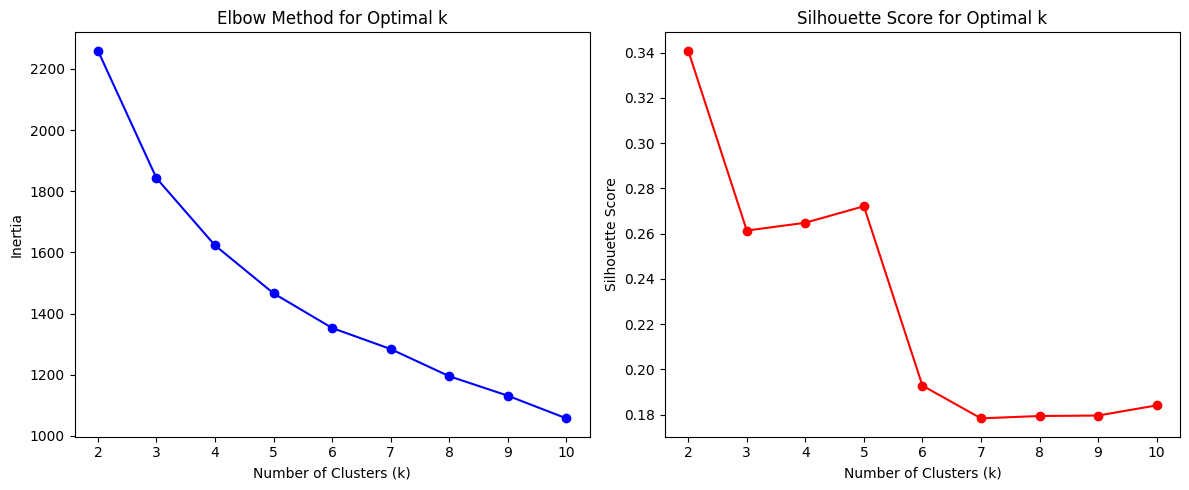

Cluster Counts:
Passing_Cluster
3    179
0    127
1     83
2     69
4      5
Name: count, dtype: int64


In [17]:
inertia = []
silhouette_scores = []
K = range(2, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(passing_features_scaled)
    inertia.append(kmeans.inertia_)
    if k > 1:
        score = silhouette_score(passing_features_scaled, kmeans.labels_)
        silhouette_scores.append(score)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(K, inertia, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')

plt.subplot(1, 2, 2)
plt.plot(range(2, 11), silhouette_scores, 'ro-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Optimal k')
plt.tight_layout()
plt.show()

optimal_k = 5
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
df_passing['Passing_Cluster'] = kmeans.fit_predict(passing_features_scaled)

print("Cluster Counts:")
print(df_passing['Passing_Cluster'].value_counts())

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


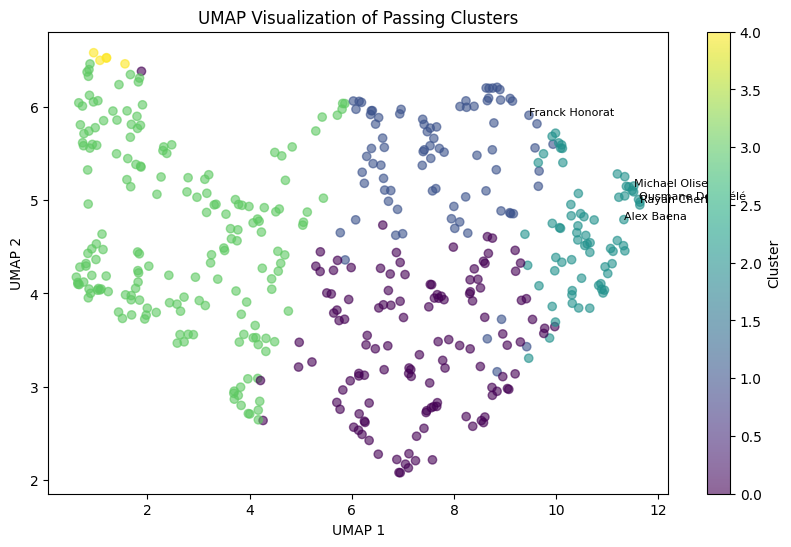

In [18]:
reducer = umap.UMAP(n_components=2, random_state=42)
passing_umap = reducer.fit_transform(passing_features_scaled)

df_umap = pd.DataFrame(passing_umap, columns=['UMAP1', 'UMAP2'])
df_umap['Cluster'] = df_passing['Passing_Cluster']
df_umap['Player'] = df_passing['Player']

plt.figure(figsize=(10, 6))
scatter = plt.scatter(df_umap['UMAP1'], df_umap['UMAP2'], c=df_umap['Cluster'], cmap='viridis', alpha=0.6)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.title('UMAP Visualization of Passing Clusters')

top_players = df_passing.sort_values('Key_Passes_per90', ascending=False).head(5)['Player']
for i, player in enumerate(df_umap['Player']):
    if player in top_players.values:
        plt.annotate(player, (df_umap['UMAP1'][i], df_umap['UMAP2'][i]), fontsize=8)

plt.show()

In [19]:
cluster_summary = df_passing.groupby('Passing_Cluster')[['Key_Passes_per90', 'Passes_into_Penalty_Area_per90',
                                                       'Crosses_into_Penalty_Area_per90', 'Progressive_Passes_per90',
                                                       'Cmp_Total_per90', 'Progressive_Distance_per90',
                                                       'Effective_Completion_Rate', 'Short_Medium_Long_Balance']].mean()
print("Cluster Summary (Average Stats per 90):")
print(cluster_summary)

for cluster in range(5):
    avg_key_passes = cluster_summary.loc[cluster, 'Key_Passes_per90']
    avg_pipa = cluster_summary.loc[cluster, 'Passes_into_Penalty_Area_per90']
    avg_cipa = cluster_summary.loc[cluster, 'Crosses_into_Penalty_Area_per90']
    avg_prog_passes = cluster_summary.loc[cluster, 'Progressive_Passes_per90']
    avg_cmp_total = cluster_summary.loc[cluster, 'Cmp_Total_per90']
    avg_prog_dist = cluster_summary.loc[cluster, 'Progressive_Distance_per90']
    avg_eff_comp = cluster_summary.loc[cluster, 'Effective_Completion_Rate']
    avg_sml_balance = cluster_summary.loc[cluster, 'Short_Medium_Long_Balance']
    print(f"Cluster {cluster}: Avg Key Passes per 90 = {avg_key_passes:.2f}, Avg Passes into Penalty Area per 90 = {avg_pipa:.2f}, "
          f"Avg Crosses into Penalty Area per 90 = {avg_cipa:.2f}, Avg Progressive Passes per 90 = {avg_prog_passes:.2f}, "
          f"Avg Completed Passes per 90 = {avg_cmp_total:.2f}, Avg Progressive Distance per 90 = {avg_prog_dist:.2f}, "
          f"Avg Effective Completion Rate = {avg_eff_comp:.2f}, Avg Short/Medium to Long Balance = {avg_sml_balance:.2f}")
    if avg_key_passes > 1.5 and avg_eff_comp > 0.1:
        print("   Suggested Label: 'Creative Playmaker' (High key passes, efficient)")
    elif avg_cipa > 0.4 and avg_pipa > 1.0:
        print("   Suggested Label: 'Winger Specialist' (High crosses, penetrates penalty area)")
    elif avg_prog_passes > 4.0 and avg_sml_balance < 15.0:
        print("   Suggested Label: 'Direct Progressor' (High progression, moderate long passes)")
    elif avg_sml_balance > 50.0 and avg_cmp_total > 10.0:
        print("   Suggested Label: 'Possession Artist' (High short-pass focus)")
    elif avg_prog_passes > 2.5 and avg_cmp_total > 20.0:
        print("   Suggested Label: 'Moderate Progressor' (Moderate progression and volume)")
    elif avg_cmp_total < 20.0 and avg_prog_passes < 2.5:
        print("   Suggested Label: 'Supportive Role' (Low activity)")
    else:
        print("   Suggested Label: 'Balanced Passer' (Moderate stats)")

df_passing.to_csv('/content/passing_with_clusters.csv', index=False)
print("\nSaved Passing dataset with clusters to '/content/passing_with_clusters.csv'")

Cluster Summary (Average Stats per 90):
                 Key_Passes_per90  Passes_into_Penalty_Area_per90  \
Passing_Cluster                                                     
0                        1.402739                        1.128522   
1                        1.485609                        1.322610   
2                        2.118297                        2.046259   
3                        0.884948                        0.478904   
4                        0.747942                        0.375624   

                 Crosses_into_Penalty_Area_per90  Progressive_Passes_per90  \
Passing_Cluster                                                              
0                                       0.194733                  3.573533   
1                                       0.570435                  2.699334   
2                                       0.418254                  5.611270   
3                                       0.093422                  1.623804   
4       

In [20]:
df_sca = pd.read_csv('/content/shot_creating_actions_cleaned.csv')

df_sca['SCA_per90'] = df_sca['SCA'] / (df_sca['Total_Minutes'] / 90)
df_sca['PassLive_per90'] = df_sca['PassLive'] / (df_sca['Total_Minutes'] / 90)
df_sca['PassDead_per90'] = df_sca['PassDead'] / (df_sca['Total_Minutes'] / 90)
df_sca['TO_per90'] = df_sca['TO'] / (df_sca['Total_Minutes'] / 90)
df_sca['Sh_per90'] = df_sca['Sh'] / (df_sca['Total_Minutes'] / 90)
df_sca['Fld_per90'] = df_sca['Fld'] / (df_sca['Total_Minutes'] / 90)
df_sca['Def_per90'] = df_sca['Def'] / (df_sca['Total_Minutes'] / 90)
df_sca['PassLive_SCA_Ratio'] = df_sca['PassLive'] / (df_sca['SCA'] + 1)
df_sca['TakeOn_SCA_Ratio'] = df_sca['TO'] / (df_sca['SCA'] + 1)
df_sca['SetPiece_SCA_Ratio'] = df_sca['PassDead'] / (df_sca['SCA'] + 1)
df_sca['Diverse_SCA_Score'] = (df_sca['PassLive'] > 0).astype(int) + (df_sca['PassDead'] > 0).astype(int) + \
                              (df_sca['TO'] > 0).astype(int) + (df_sca['Sh'] > 0).astype(int) + \
                              (df_sca['Fld'] > 0).astype(int) + (df_sca['Def'] > 0).astype(int)

sca_features = df_sca[['SCA_per90', 'PassLive_per90', 'PassDead_per90', 'TO_per90', 'Sh_per90', 'Fld_per90',
                      'Def_per90', 'PassLive_SCA_Ratio', 'TakeOn_SCA_Ratio', 'SetPiece_SCA_Ratio', 'Diverse_SCA_Score']]

scaler = StandardScaler()
sca_features_scaled = scaler.fit_transform(sca_features)

print("Prepared Features (first 5 rows):")
print(pd.DataFrame(sca_features_scaled, columns=['SCA_per90', 'PassLive_per90', 'PassDead_per90', 'TO_per90',
                                                'Sh_per90', 'Fld_per90', 'Def_per90', 'PassLive_SCA_Ratio',
                                                'TakeOn_SCA_Ratio', 'SetPiece_SCA_Ratio', 'Diverse_SCA_Score']).head())

Prepared Features (first 5 rows):
   SCA_per90  PassLive_per90  PassDead_per90  TO_per90  Sh_per90  Fld_per90  \
0   2.427867        2.185249        1.003308  0.988020  2.604665   0.341322   
1   2.626608        1.867878       -0.398215  4.538156  2.876961   1.257532   
2   2.562361        2.132282        3.330100 -0.502105  1.068298  -0.320427   
3   3.132215        3.272808        1.172953  1.581060  0.255649   1.250523   
4   1.372748        1.564353       -0.513781  1.637532  1.019694  -0.357324   

   Def_per90  PassLive_SCA_Ratio  TakeOn_SCA_Ratio  SetPiece_SCA_Ratio  \
0   0.320805           -0.146066          0.017248            0.446106   
1   1.682374           -0.826918          2.184509           -0.540529   
2  -0.106050           -0.396239         -0.962986            1.997770   
3  -0.783472            0.375028          0.184216            0.407257   
4   0.785222            0.493685          0.914254           -0.586813   

   Diverse_SCA_Score  
0           1.221950  


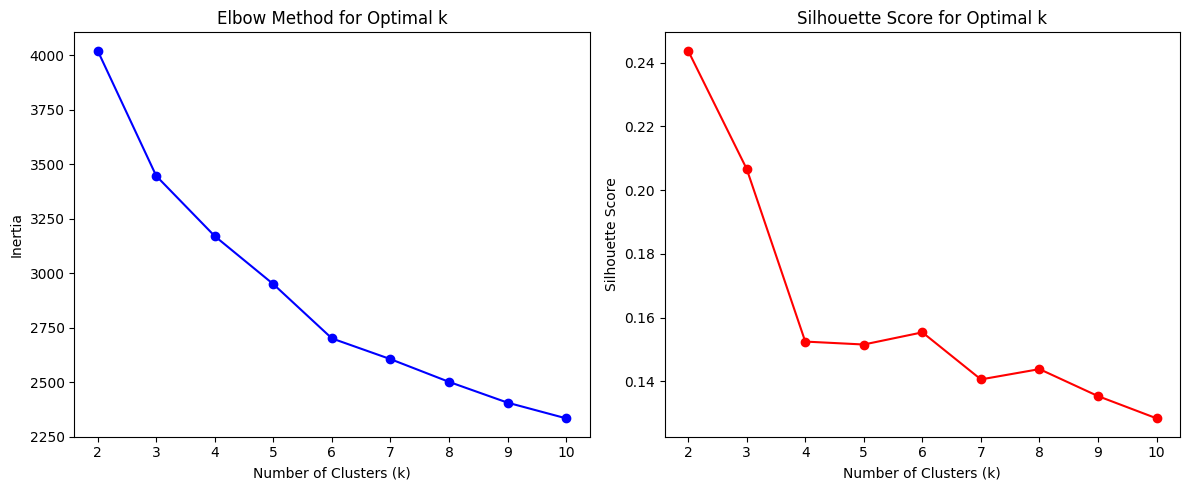

Cluster Counts:
SCA_Cluster
4    108
5     93
3     86
2     64
0     60
1     52
Name: count, dtype: int64


In [21]:
inertia = []
silhouette_scores = []
K = range(2, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(sca_features_scaled)
    inertia.append(kmeans.inertia_)
    if k > 1:
        score = silhouette_score(sca_features_scaled, kmeans.labels_)
        silhouette_scores.append(score)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(K, inertia, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')

plt.subplot(1, 2, 2)
plt.plot(range(2, 11), silhouette_scores, 'ro-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Optimal k')
plt.tight_layout()
plt.show()

optimal_k = 6
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
df_sca['SCA_Cluster'] = kmeans.fit_predict(sca_features_scaled)

print("Cluster Counts:")
print(df_sca['SCA_Cluster'].value_counts())

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


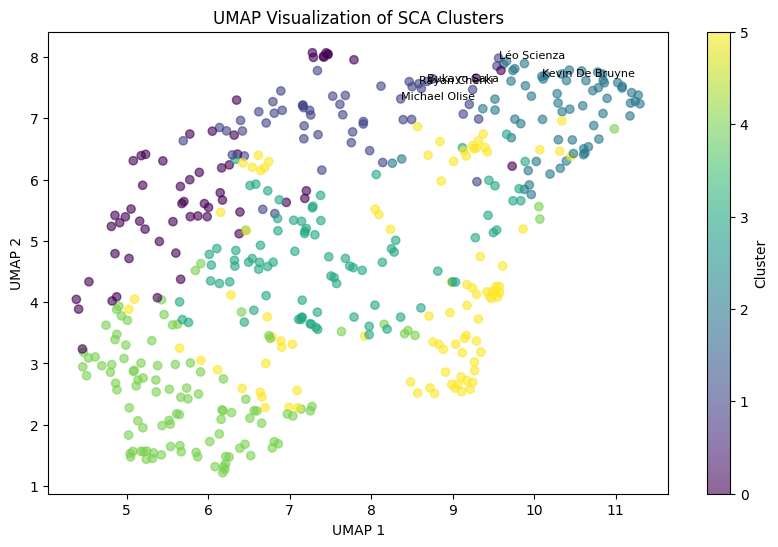

In [22]:
reducer = umap.UMAP(n_components=2, random_state=42)
sca_umap = reducer.fit_transform(sca_features_scaled)

df_umap = pd.DataFrame(sca_umap, columns=['UMAP1', 'UMAP2'])
df_umap['Cluster'] = df_sca['SCA_Cluster']
df_umap['Player'] = df_sca['Player']

plt.figure(figsize=(10, 6))
scatter = plt.scatter(df_umap['UMAP1'], df_umap['UMAP2'], c=df_umap['Cluster'], cmap='viridis', alpha=0.6)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.title('UMAP Visualization of SCA Clusters')

top_players = df_sca.sort_values('SCA_per90', ascending=False).head(5)['Player']
for i, player in enumerate(df_umap['Player']):
    if player in top_players.values:
        plt.annotate(player, (df_umap['UMAP1'][i], df_umap['UMAP2'][i]), fontsize=8)

plt.show()

In [23]:
cluster_summary = df_sca.groupby('SCA_Cluster')[['SCA_per90', 'PassLive_per90', 'PassDead_per90', 'TO_per90',
                                                'Sh_per90', 'Fld_per90', 'Def_per90', 'PassLive_SCA_Ratio',
                                                'TakeOn_SCA_Ratio', 'SetPiece_SCA_Ratio', 'Diverse_SCA_Score']].mean()
print("Cluster Summary (Average Stats per 90):")
print(cluster_summary)

for cluster in range(6):
    avg_sca = cluster_summary.loc[cluster, 'SCA_per90']
    avg_passlive = cluster_summary.loc[cluster, 'PassLive_per90']
    avg_passdead = cluster_summary.loc[cluster, 'PassDead_per90']
    avg_to = cluster_summary.loc[cluster, 'TO_per90']
    avg_sh = cluster_summary.loc[cluster, 'Sh_per90']
    avg_fld = cluster_summary.loc[cluster, 'Fld_per90']
    avg_def = cluster_summary.loc[cluster, 'Def_per90']
    avg_passlive_ratio = cluster_summary.loc[cluster, 'PassLive_SCA_Ratio']
    avg_to_ratio = cluster_summary.loc[cluster, 'TakeOn_SCA_Ratio']
    avg_setpiece_ratio = cluster_summary.loc[cluster, 'SetPiece_SCA_Ratio']
    avg_diverse_score = cluster_summary.loc[cluster, 'Diverse_SCA_Score']
    print(f"Cluster {cluster}: Avg SCA per 90 = {avg_sca:.2f}, Avg PassLive per 90 = {avg_passlive:.2f}, "
          f"Avg PassDead per 90 = {avg_passdead:.2f}, Avg TO per 90 = {avg_to:.2f}, "
          f"Avg Sh per 90 = {avg_sh:.2f}, Avg Fld per 90 = {avg_fld:.2f}, Avg Def per 90 = {avg_def:.2f}, "
          f"Avg PassLive SCA Ratio = {avg_passlive_ratio:.2f}, Avg TakeOn SCA Ratio = {avg_to_ratio:.2f}, "
          f"Avg SetPiece SCA Ratio = {avg_setpiece_ratio:.2f}, Avg Diverse SCA Score = {avg_diverse_score:.2f}")
    if avg_sca > 4.5 and avg_diverse_score > 5.0:
        print("   Suggested Label: 'Elite Versatile Creator' (High SCA, broad contribution)")
    elif avg_to > 0.4 and avg_to_ratio > 0.15:
        print("   Suggested Label: 'Dribble-Focused Creator' (High take-on reliance)")
    elif avg_passdead > 0.5 and avg_setpiece_ratio > 0.2:
        print("   Suggested Label: 'Set-Piece Specialist' (Significant set-piece contribution)")
    elif avg_passlive_ratio > 0.75 and avg_passlive > 2.0:
        print("   Suggested Label: 'Pass-Dominant Creator' (Pass-heavy style)")
    elif avg_sca > 2.0 and avg_diverse_score > 4.0:
        print("   Suggested Label: 'Supporting Versatile Creator' (Balanced contribution)")
    elif avg_sca < 2.0:
        print("   Suggested Label: 'Low-Impact Creator' (Low SCA activity)")
    else:
        print("   Suggested Label: 'Balanced Creator' (Moderate SCA stats)")

df_sca.to_csv('/content/sca_with_clusters.csv', index=False)
print("\nSaved SCA dataset with clusters to '/content/sca_with_clusters.csv'")

Cluster Summary (Average Stats per 90):
             SCA_per90  PassLive_per90  PassDead_per90  TO_per90  Sh_per90  \
SCA_Cluster                                                                  
0             2.879818        1.741946        0.124340  0.490842  0.263223   
1             4.706647        3.106331        0.384778  0.570908  0.309335   
2             3.815517        2.307597        0.914082  0.146428  0.233750   
3             2.382681        1.594582        0.087047  0.177697  0.243550   
4             1.828583        1.336224        0.022608  0.108342  0.207081   
5             3.321319        2.653607        0.139679  0.183336  0.189400   

             Fld_per90  Def_per90  PassLive_SCA_Ratio  TakeOn_SCA_Ratio  \
SCA_Cluster                                                               
0             0.231197   0.028271            0.589015          0.169441   
1             0.266238   0.069057            0.655162          0.119613   
2             0.170899   0.042762  

In [24]:
df_gca = pd.read_csv('/content/goal_creating_actions_cleaned.csv')

df_gca['GCA_per90'] = df_gca['GCA'] / (df_gca['Total_Minutes'] / 90)
df_gca['PassLive_per90'] = df_gca['PassLive'] / (df_gca['Total_Minutes'] / 90)
df_gca['PassDead_per90'] = df_gca['PassDead'] / (df_gca['Total_Minutes'] / 90)
df_gca['TO_per90'] = df_gca['TO'] / (df_gca['Total_Minutes'] / 90)
df_gca['Sh_per90'] = df_gca['Sh'] / (df_gca['Total_Minutes'] / 90)
df_gca['Fld_per90'] = df_gca['Fld'] / (df_gca['Total_Minutes'] / 90)
df_gca['Def_GCA_per90'] = df_gca['Def_GCA'] / (df_gca['Total_Minutes'] / 90)
df_gca['PassLive_GCA_Ratio'] = df_gca['PassLive'] / (df_gca['GCA'] + 1)
df_gca['TakeOn_GCA_Ratio'] = df_gca['TO'] / (df_gca['GCA'] + 1)
df_gca['SetPiece_GCA_Ratio'] = df_gca['PassDead'] / (df_gca['GCA'] + 1)
df_gca['Diverse_GCA_Score'] = (df_gca['PassLive'] > 0).astype(int) + (df_gca['PassDead'] > 0).astype(int) + \
                              (df_gca['TO'] > 0).astype(int) + (df_gca['Sh'] > 0).astype(int) + \
                              (df_gca['Fld'] > 0).astype(int) + (df_gca['Def_GCA'] > 0).astype(int)

gca_features = df_gca[['GCA_per90', 'PassLive_per90', 'PassDead_per90', 'TO_per90', 'Sh_per90', 'Fld_per90',
                      'Def_GCA_per90', 'PassLive_GCA_Ratio', 'TakeOn_GCA_Ratio', 'SetPiece_GCA_Ratio',
                      'Diverse_GCA_Score']]

scaler = StandardScaler()
gca_features_scaled = scaler.fit_transform(gca_features)

print("Prepared Features (first 5 rows):")
print(pd.DataFrame(gca_features_scaled, columns=['GCA_per90', 'PassLive_per90', 'PassDead_per90', 'TO_per90',
                                                'Sh_per90', 'Fld_per90', 'Def_GCA_per90', 'PassLive_GCA_Ratio',
                                                'TakeOn_GCA_Ratio', 'SetPiece_GCA_Ratio', 'Diverse_GCA_Score']).head())

Prepared Features (first 5 rows):
   GCA_per90  PassLive_per90  PassDead_per90  TO_per90  Sh_per90  Fld_per90  \
0   2.820631        2.696571       -0.441798  2.277883  0.692457   0.748437   
1   1.852134        2.049982       -0.441798  1.830548  0.466085  -0.689811   
2   3.233412        3.096222       -0.441798  2.196172  1.919985   0.184173   
3   3.054748        1.811842        2.404338  0.767615  1.928077   2.816531   
4   4.484593        3.691955       -0.441798  3.208929  0.427616   2.858776   

   Def_GCA_per90  PassLive_GCA_Ratio  TakeOn_GCA_Ratio  SetPiece_GCA_Ratio  \
0      -0.276430            0.615412          0.815007           -0.455520   
1      -0.276430            0.842163          0.922844           -0.455520   
2      -0.276430            0.615412          0.647260           -0.455520   
3      -0.276430           -0.178217          0.002080            0.979607   
4       2.464231            0.297960          0.754618           -0.455520   

   Diverse_GCA_Score  

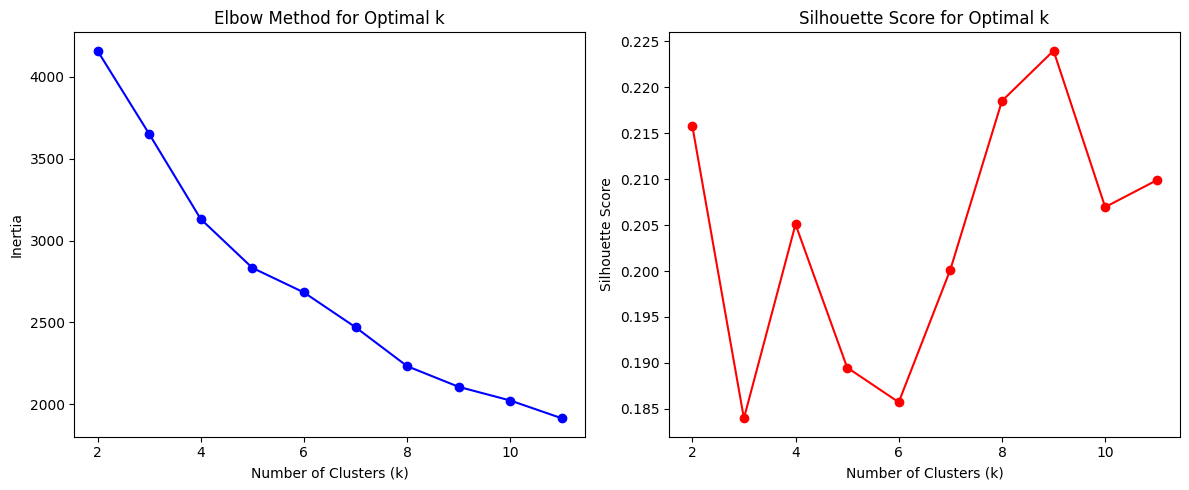

Cluster Counts:
GCA_Cluster
1    181
0    127
2    100
3     55
Name: count, dtype: int64


In [25]:
inertia = []
silhouette_scores = []
K = range(2, 12)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(gca_features_scaled)
    inertia.append(kmeans.inertia_)
    if k > 1:
        score = silhouette_score(gca_features_scaled, kmeans.labels_)
        silhouette_scores.append(score)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(K, inertia, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')

plt.subplot(1, 2, 2)
plt.plot(range(2, 12), silhouette_scores, 'ro-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Optimal k')
plt.tight_layout()
plt.show()

optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
df_gca['GCA_Cluster'] = kmeans.fit_predict(gca_features_scaled)

print("Cluster Counts:")
print(df_gca['GCA_Cluster'].value_counts())

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


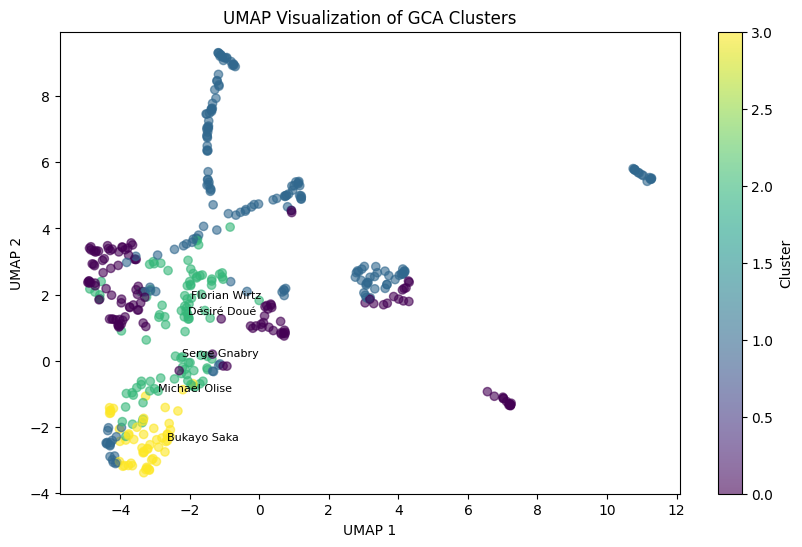

In [26]:
reducer = umap.UMAP(n_components=2, random_state=42)
gca_umap = reducer.fit_transform(gca_features_scaled)

df_umap = pd.DataFrame(gca_umap, columns=['UMAP1', 'UMAP2'])
df_umap['Cluster'] = df_gca['GCA_Cluster']
df_umap['Player'] = df_gca['Player']

plt.figure(figsize=(10, 6))
scatter = plt.scatter(df_umap['UMAP1'], df_umap['UMAP2'], c=df_umap['Cluster'], cmap='viridis', alpha=0.6)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.title('UMAP Visualization of GCA Clusters')

top_players = df_gca.sort_values('GCA_per90', ascending=False).head(5)['Player']
for i, player in enumerate(df_umap['Player']):
    if player in top_players.values:
        plt.annotate(player, (df_umap['UMAP1'][i], df_umap['UMAP2'][i]), fontsize=8)

plt.show()

In [27]:
cluster_summary = df_gca.groupby('GCA_Cluster')[['GCA_per90', 'PassLive_per90', 'PassDead_per90', 'TO_per90',
                                                'Sh_per90', 'Fld_per90', 'Def_GCA_per90', 'PassLive_GCA_Ratio',
                                                'TakeOn_GCA_Ratio', 'SetPiece_GCA_Ratio', 'Diverse_GCA_Score']].mean()
print("Cluster Summary (Average Stats per 90):")
print(cluster_summary)

for cluster in range(4):
    avg_gca = cluster_summary.loc[cluster, 'GCA_per90']
    avg_passlive = cluster_summary.loc[cluster, 'PassLive_per90']
    avg_passdead = cluster_summary.loc[cluster, 'PassDead_per90']
    avg_to = cluster_summary.loc[cluster, 'TO_per90']
    avg_sh = cluster_summary.loc[cluster, 'Sh_per90']
    avg_fld = cluster_summary.loc[cluster, 'Fld_per90']
    avg_def_gca = cluster_summary.loc[cluster, 'Def_GCA_per90']
    avg_passlive_ratio = cluster_summary.loc[cluster, 'PassLive_GCA_Ratio']
    avg_to_ratio = cluster_summary.loc[cluster, 'TakeOn_GCA_Ratio']
    avg_setpiece_ratio = cluster_summary.loc[cluster, 'SetPiece_GCA_Ratio']
    avg_diverse_score = cluster_summary.loc[cluster, 'Diverse_GCA_Score']
    print(f"Cluster {cluster}: Avg GCA per 90 = {avg_gca:.2f}, Avg PassLive per 90 = {avg_passlive:.2f}, "
          f"Avg PassDead per 90 = {avg_passdead:.2f}, Avg TO per 90 = {avg_to:.2f}, "
          f"Avg Sh per 90 = {avg_sh:.2f}, Avg Fld per 90 = {avg_fld:.2f}, Avg Def_GCA per 90 = {avg_def_gca:.2f}, "
          f"Avg PassLive GCA Ratio = {avg_passlive_ratio:.2f}, Avg TakeOn GCA Ratio = {avg_to_ratio:.2f}, "
          f"Avg SetPiece GCA Ratio = {avg_setpiece_ratio:.2f}, Avg Diverse GCA Score = {avg_diverse_score:.2f}")
    if avg_gca > 0.8:
        print("   Suggested Label: 'Elite Goal Creator' (High GCA rate)")
    elif avg_passlive_ratio > 0.6 and avg_gca > 0.25:
        print("   Suggested Label: 'Pass-Dominant Playmaker' (Pass-heavy, low GCA)")
    elif avg_to_ratio > 0.12 and avg_gca > 0.5:
        print("   Suggested Label: 'Dribble-Driven Finisher' (Dribble-heavy, higher GCA)")
    elif avg_setpiece_ratio > 0.15 and avg_gca > 0.4:
        print("   Suggested Label: 'Set-Piece Maestro' (Significant set-piece contribution)")
    elif avg_gca < 0.3 and avg_diverse_score > 2.0:
        print("   Suggested Label: 'Minimally Diverse Low-Impact Creator' (Low GCA, slight diversity)")
    elif avg_gca < 0.3:
        print("   Suggested Label: 'Pass-Focused Low-Impact Creator' (Low GCA, pass-heavy)")
    else:
        print("   Suggested Label: 'Balanced Goal Creator' (Moderate GCA stats)")

df_gca.to_csv('/content/gca_with_clusters.csv', index=False)
print("\nSaved GCA dataset with clusters to '/content/gca_with_clusters.csv'")

Cluster Summary (Average Stats per 90):
             GCA_per90  PassLive_per90  PassDead_per90  TO_per90  Sh_per90  \
GCA_Cluster                                                                  
0             0.241491        0.105583        0.000756  0.040010  0.051802   
1             0.269826        0.228019        0.003643  0.004364  0.017781   
2             0.596785        0.383862        0.016522  0.092211  0.047746   
3             0.439770        0.247702        0.106234  0.025721  0.018202   

             Fld_per90  Def_GCA_per90  PassLive_GCA_Ratio  TakeOn_GCA_Ratio  \
GCA_Cluster                                                                   
0             0.040701       0.002638            0.315840          0.128429   
1             0.014281       0.001739            0.679368          0.011198   
2             0.042697       0.013748            0.592656          0.143618   
3             0.034878       0.007032            0.481557          0.051089   

             Set

In [28]:
df_carries = pd.read_csv('/content/carries_cleaned.csv')

df_carries['Carries_per90'] = df_carries['Carries'] / (df_carries['Total_Minutes'] / 90)
df_carries['PrgDist_per90'] = df_carries['PrgDist'] / (df_carries['Total_Minutes'] / 90)
df_carries['PrgC_per90'] = df_carries['PrgC'] / (df_carries['Total_Minutes'] / 90)
df_carries['FinalThird_per90'] = df_carries['1/3'] / (df_carries['Total_Minutes'] / 90)
df_carries['CPA_per90'] = df_carries['CPA'] / (df_carries['Total_Minutes'] / 90)
df_carries['Mis_per90'] = df_carries['Mis'] / (df_carries['Total_Minutes'] / 90)
df_carries['Dis_per90'] = df_carries['Dis'] / (df_carries['Total_Minutes'] / 90)
df_carries['PrgR_per90'] = df_carries['PrgR'] / (df_carries['Total_Minutes'] / 90)
df_carries['PrgDist_per_Carry'] = df_carries['PrgDist'] / (df_carries['Carries'] + 1)
df_carries['Penetration_Ratio'] = df_carries['CPA'] / (df_carries['Carries'] + 1)
df_carries['Error_Rate'] = (df_carries['Mis'] + df_carries['Dis']) / (df_carries['Carries'] + 1)
df_carries['Progressive_Carry_Ratio'] = df_carries['PrgC'] / (df_carries['Carries'] + 1)
df_carries['Progressive_Receive_Ratio'] = df_carries['PrgR'] / (df_carries['Rec'] + 1)

carry_features = df_carries[['Carries_per90', 'PrgDist_per90', 'PrgC_per90', 'FinalThird_per90', 'CPA_per90',
                            'Mis_per90', 'Dis_per90', 'PrgR_per90', 'PrgDist_per_Carry', 'Penetration_Ratio',
                            'Error_Rate', 'Progressive_Carry_Ratio', 'Progressive_Receive_Ratio']]

scaler = StandardScaler()
carry_features_scaled = scaler.fit_transform(carry_features)

print("Prepared Features (first 5 rows):")
print(pd.DataFrame(carry_features_scaled, columns=['Carries_per90', 'PrgDist_per90', 'PrgC_per90', 'FinalThird_per90',
                                                  'CPA_per90', 'Mis_per90', 'Dis_per90', 'PrgR_per90',
                                                  'PrgDist_per_Carry', 'Penetration_Ratio', 'Error_Rate',
                                                  'Progressive_Carry_Ratio', 'Progressive_Receive_Ratio']).head())

Prepared Features (first 5 rows):
   Carries_per90  PrgDist_per90  PrgC_per90  FinalThird_per90  CPA_per90  \
0       2.641899       2.376142    2.125251          1.727865   2.448315   
1       1.772351       1.507267    1.223529          1.900074   0.119397   
2       3.062837       1.887882    1.383864          1.294520   0.934377   
3       2.230793       1.621588    0.596534          0.736221   0.071713   
4       2.613097       1.698633    1.667229          1.408170   1.251016   

   Mis_per90  Dis_per90  PrgR_per90  PrgDist_per_Carry  Penetration_Ratio  \
0   1.119798   0.198321    2.892256           0.828495           0.903624   
1  -0.675045  -0.417136    0.386482           0.598756          -0.473574   
2  -0.135951  -0.580657    3.314012           0.166624          -0.201959   
3  -2.051040  -0.529778    0.110244           0.400830          -0.602946   
4  -0.209129   0.664971    2.160443           0.244110           0.117853   

   Error_Rate  Progressive_Carry_Ratio  Progre

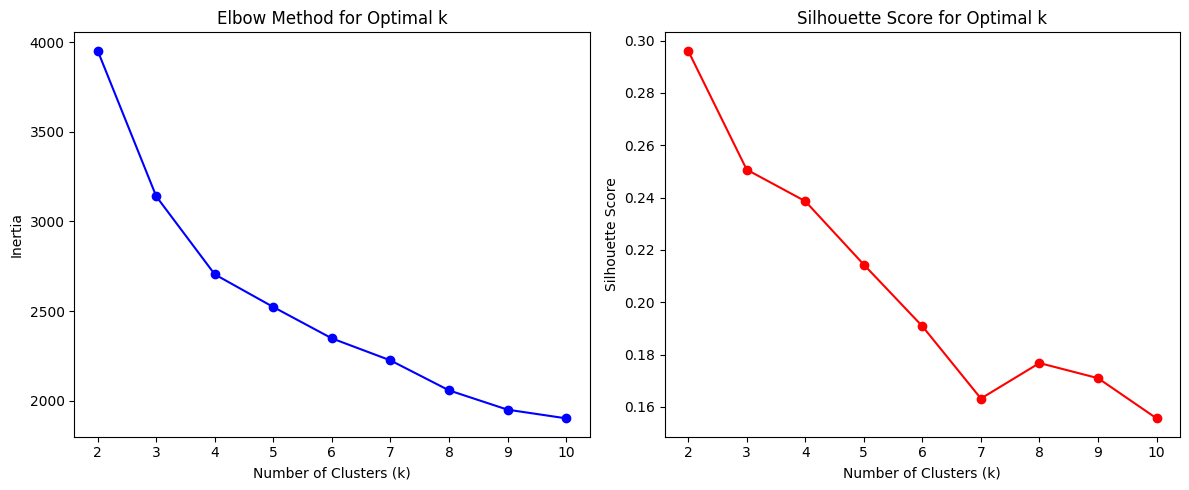

Cluster Counts:
Carries_Cluster
3    137
0    126
1    121
2     76
Name: count, dtype: int64


In [29]:
inertia = []
silhouette_scores = []
K = range(2, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(carry_features_scaled)
    inertia.append(kmeans.inertia_)
    if k > 1:
        score = silhouette_score(carry_features_scaled, kmeans.labels_)
        silhouette_scores.append(score)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(K, inertia, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')

plt.subplot(1, 2, 2)
plt.plot(range(2, 11), silhouette_scores, 'ro-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Optimal k')
plt.tight_layout()
plt.show()

optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
df_carries['Carries_Cluster'] = kmeans.fit_predict(carry_features_scaled)

print("Cluster Counts:")
print(df_carries['Carries_Cluster'].value_counts())

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


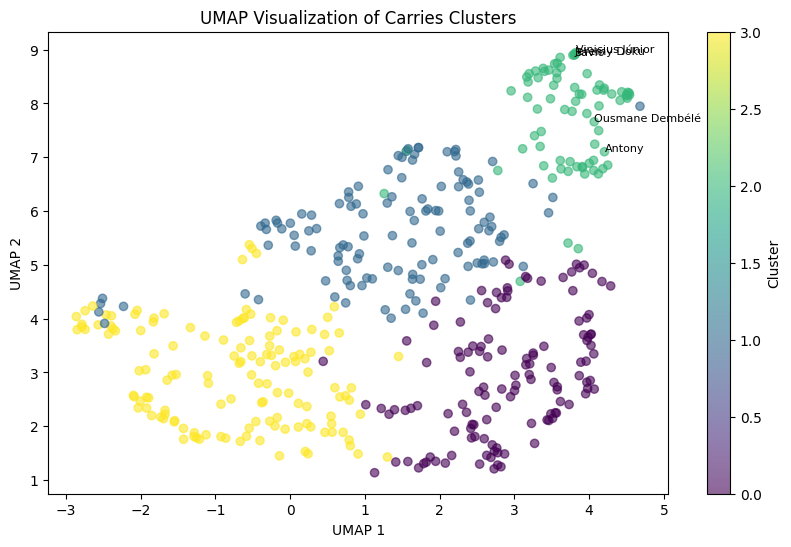

In [30]:
reducer = umap.UMAP(n_components=2, random_state=42)
carry_umap = reducer.fit_transform(carry_features_scaled)

df_umap = pd.DataFrame(carry_umap, columns=['UMAP1', 'UMAP2'])
df_umap['Cluster'] = df_carries['Carries_Cluster']
df_umap['Player'] = df_carries['Player']

plt.figure(figsize=(10, 6))
scatter = plt.scatter(df_umap['UMAP1'], df_umap['UMAP2'], c=df_umap['Cluster'], cmap='viridis', alpha=0.6)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.title('UMAP Visualization of Carries Clusters')

top_players = df_carries.sort_values('PrgDist_per90', ascending=False).head(5)['Player']
for i, player in enumerate(df_umap['Player']):
    if player in top_players.values:
        plt.annotate(player, (df_umap['UMAP1'][i], df_umap['UMAP2'][i]), fontsize=8)

plt.show()

In [31]:
cluster_summary = df_carries.groupby('Carries_Cluster')[['Carries_per90', 'PrgDist_per90', 'PrgC_per90',
                                                       'FinalThird_per90', 'CPA_per90', 'Mis_per90', 'Dis_per90',
                                                       'PrgR_per90', 'PrgDist_per_Carry', 'Penetration_Ratio',
                                                       'Error_Rate', 'Progressive_Carry_Ratio',
                                                       'Progressive_Receive_Ratio']].mean()
print("Cluster Summary (Average Stats per 90):")
print(cluster_summary)

for cluster in range(4):
    avg_carries = cluster_summary.loc[cluster, 'Carries_per90']
    avg_prgdist = cluster_summary.loc[cluster, 'PrgDist_per90']
    avg_prgc = cluster_summary.loc[cluster, 'PrgC_per90']
    avg_finalthird = cluster_summary.loc[cluster, 'FinalThird_per90']
    avg_cpa = cluster_summary.loc[cluster, 'CPA_per90']
    avg_mis = cluster_summary.loc[cluster, 'Mis_per90']
    avg_dis = cluster_summary.loc[cluster, 'Dis_per90']
    avg_prgr = cluster_summary.loc[cluster, 'PrgR_per90']
    avg_prgdist_per_carry = cluster_summary.loc[cluster, 'PrgDist_per_Carry']
    avg_penetration = cluster_summary.loc[cluster, 'Penetration_Ratio']
    avg_error = cluster_summary.loc[cluster, 'Error_Rate']
    avg_prog_carry_ratio = cluster_summary.loc[cluster, 'Progressive_Carry_Ratio']
    avg_prog_receive_ratio = cluster_summary.loc[cluster, 'Progressive_Receive_Ratio']
    print(f"Cluster {cluster}: Avg Carries per 90 = {avg_carries:.2f}, Avg PrgDist per 90 = {avg_prgdist:.2f}, "
          f"Avg PrgC per 90 = {avg_prgc:.2f}, Avg FinalThird per 90 = {avg_finalthird:.2f}, "
          f"Avg CPA per 90 = {avg_cpa:.2f}, Avg Mis per 90 = {avg_mis:.2f}, Avg Dis per 90 = {avg_dis:.2f}, "
          f"Avg PrgR per 90 = {avg_prgr:.2f}, Avg PrgDist per Carry = {avg_prgdist_per_carry:.2f}, "
          f"Avg Penetration Ratio = {avg_penetration:.3f}, Avg Error Rate = {avg_error:.3f}, "
          f"Avg Progressive Carry Ratio = {avg_prog_carry_ratio:.3f}, "
          f"Avg Progressive Receive Ratio = {avg_prog_receive_ratio:.3f}")
    if avg_prgdist > 120 and avg_cpa > 1.5:
        print("   Suggested Label: 'Direct Penetrator' (High progression, penalty area entries)")
    elif avg_prgc > 2.0 and avg_error < 0.1:
        print("   Suggested Label: 'Reliable Progressor' (High progressive carries, low errors)")
    elif avg_error > 0.15 and avg_cpa > 1.0:
        print("   Suggested Label: 'Risky Penetrator' (High error rate, high penetration)")
    elif avg_error > 0.15 and avg_prgdist < 50:
        print("   Suggested Label: 'Ineffective Risky Carrier' (High error rate, low progression)")
    else:
        print("   Suggested Label: 'Balanced Carrier' (Moderate carrying stats)")

df_carries.to_csv('/content/carries_with_clusters.csv', index=False)
print("\nSaved Carries dataset with clusters to '/content/carries_with_clusters.csv'")

Cluster Summary (Average Stats per 90):
                 Carries_per90  PrgDist_per90  PrgC_per90  FinalThird_per90  \
Carries_Cluster                                                               
0                    30.706091      82.407428    2.331811          1.780182   
1                    22.738529      72.341892    2.777050          1.627803   
2                    33.145637     132.001900    5.009775          2.660946   
3                    16.898714      30.422946    1.042111          0.726093   

                 CPA_per90  Mis_per90  Dis_per90  PrgR_per90  \
Carries_Cluster                                                
0                 0.626172   1.753080   1.179341    5.755692   
1                 1.207393   2.815647   1.656928    6.672785   
2                 2.366007   2.382834   1.532999   10.171155   
3                 0.472917   2.559320   1.422094    4.887971   

                 PrgDist_per_Carry  Penetration_Ratio  Error_Rate  \
Carries_Cluster                

In [32]:
df_touches = pd.read_csv('/content/touches_cleaned.csv')

df_touches['Touches_per90'] = df_touches['Touches'] / (df_touches['Total_Minutes'] / 90)
df_touches['Live_per90'] = df_touches['Live'] / (df_touches['Total_Minutes'] / 90)
df_touches['DefPen_per90'] = df_touches['Def Pen'] / (df_touches['Total_Minutes'] / 90)
df_touches['Def3rd_per90'] = df_touches['Def 3rd'] / (df_touches['Total_Minutes'] / 90)
df_touches['Mid3rd_per90'] = df_touches['Mid 3rd'] / (df_touches['Total_Minutes'] / 90)
df_touches['Att3rd_per90'] = df_touches['Att 3rd'] / (df_touches['Total_Minutes'] / 90)
df_touches['AttPen_per90'] = df_touches['Att Pen'] / (df_touches['Total_Minutes'] / 90)
df_touches['Att3rd_Ratio'] = df_touches['Att 3rd'] / (df_touches['Touches'] + 1)
df_touches['AttPen_Ratio'] = df_touches['Att Pen'] / (df_touches['Touches'] + 1)
df_touches['Def3rd_Ratio'] = df_touches['Def 3rd'] / (df_touches['Touches'] + 1)
df_touches['Live_Ratio'] = df_touches['Live'] / (df_touches['Touches'] + 1)
df_touches['Attacking_Touch_Score'] = (df_touches['Att 3rd'] + df_touches['Att Pen']) / (df_touches['Def 3rd'] + 1)

touch_features = df_touches[['Touches_per90', 'Live_per90', 'DefPen_per90', 'Def3rd_per90', 'Mid3rd_per90',
                            'Att3rd_per90', 'AttPen_per90', 'Att3rd_Ratio', 'AttPen_Ratio', 'Def3rd_Ratio',
                            'Live_Ratio', 'Attacking_Touch_Score']]

scaler = StandardScaler()
touch_features_scaled = scaler.fit_transform(touch_features)

print("Prepared Features (first 5 rows):")
print(pd.DataFrame(touch_features_scaled, columns=['Touches_per90', 'Live_per90', 'DefPen_per90', 'Def3rd_per90',
                                                  'Mid3rd_per90', 'Att3rd_per90', 'AttPen_per90', 'Att3rd_Ratio',
                                                  'AttPen_Ratio', 'Def3rd_Ratio', 'Live_Ratio',
                                                  'Attacking_Touch_Score']).head())

Prepared Features (first 5 rows):
   Touches_per90  Live_per90  DefPen_per90  Def3rd_per90  Mid3rd_per90  \
0       3.150993    3.138857     -0.924014     -0.110510      2.231253   
1       1.957474    1.958998     -1.077432     -0.642663      0.519944   
2       2.229544    2.230876      1.090450      2.141099      1.768009   
3       1.716825    1.707917      0.345003      1.280045      3.112890   
4       2.751043    2.752005     -0.442626     -0.370773      1.300111   

   Att3rd_per90  AttPen_per90  Att3rd_Ratio  AttPen_Ratio  Def3rd_Ratio  \
0      3.637682      0.735851      0.974570     -0.766293     -1.111737   
1      3.336196      1.903832      1.947722      0.072636     -1.335100   
2      1.380514      0.429888     -0.488482     -0.701582      0.980591   
3     -0.163437     -1.561728     -1.863518     -1.569990      0.495123   
4      3.859129      1.023520      1.577974     -0.564058     -1.240943   

   Live_Ratio  Attacking_Touch_Score  
0   -0.034450               1.1

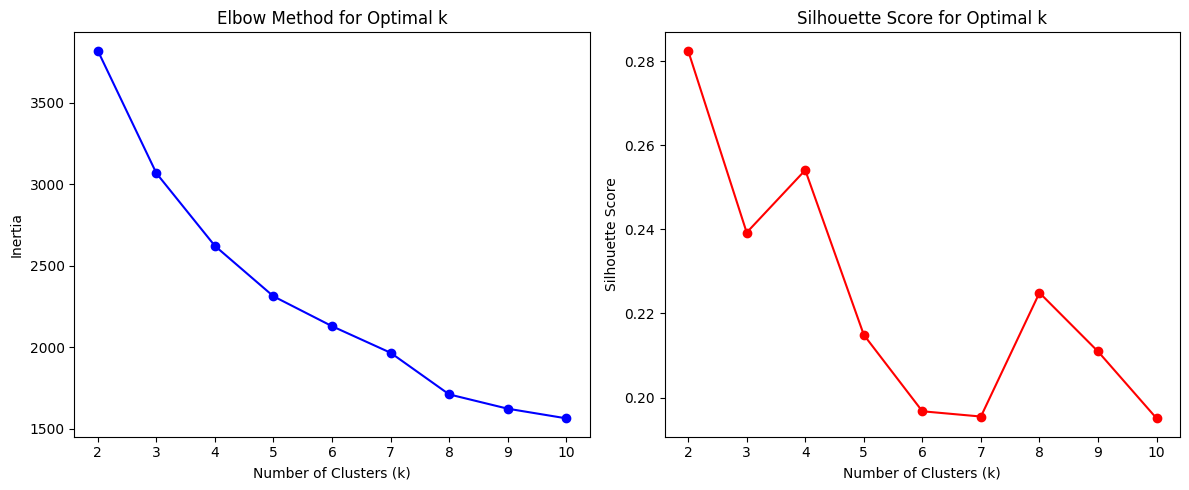

Cluster Counts:
Touches_Cluster
0    133
3    132
1    131
4     36
2     28
Name: count, dtype: int64


In [33]:
inertia = []
silhouette_scores = []
K = range(2, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(touch_features_scaled)
    inertia.append(kmeans.inertia_)
    if k > 1:
        score = silhouette_score(touch_features_scaled, kmeans.labels_)
        silhouette_scores.append(score)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(K, inertia, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')

plt.subplot(1, 2, 2)
plt.plot(range(2, 11), silhouette_scores, 'ro-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Optimal k')
plt.tight_layout()
plt.show()

optimal_k = 5
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
df_touches['Touches_Cluster'] = kmeans.fit_predict(touch_features_scaled)

print("Cluster Counts:")
print(df_touches['Touches_Cluster'].value_counts())

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


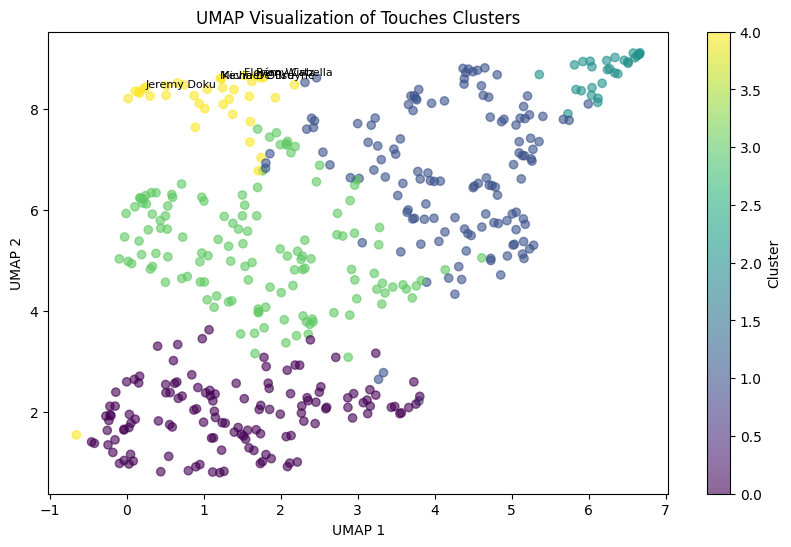

In [34]:
reducer = umap.UMAP(n_components=2, random_state=42)
touch_umap = reducer.fit_transform(touch_features_scaled)

df_umap = pd.DataFrame(touch_umap, columns=['UMAP1', 'UMAP2'])
df_umap['Cluster'] = df_touches['Touches_Cluster']
df_umap['Player'] = df_touches['Player']

plt.figure(figsize=(10, 6))
scatter = plt.scatter(df_umap['UMAP1'], df_umap['UMAP2'], c=df_umap['Cluster'], cmap='viridis', alpha=0.6)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.title('UMAP Visualization of Touches Clusters')

top_players = df_touches.sort_values('Att3rd_per90', ascending=False).head(5)['Player']
for i, player in enumerate(df_umap['Player']):
    if player in top_players.values:
        plt.annotate(player, (df_umap['UMAP1'][i], df_umap['UMAP2'][i]), fontsize=8)

plt.show()

In [35]:
cluster_summary = df_touches.groupby('Touches_Cluster')[['Touches_per90', 'Live_per90', 'DefPen_per90',
                                                       'Def3rd_per90', 'Mid3rd_per90', 'Att3rd_per90',
                                                       'AttPen_per90', 'Att3rd_Ratio', 'AttPen_Ratio',
                                                       'Def3rd_Ratio', 'Live_Ratio', 'Attacking_Touch_Score']].mean()
print("Cluster Summary (Average Stats per 90):")
print(cluster_summary)

for cluster in range(5):
    avg_touches = cluster_summary.loc[cluster, 'Touches_per90']
    avg_live = cluster_summary.loc[cluster, 'Live_per90']
    avg_defpen = cluster_summary.loc[cluster, 'DefPen_per90']
    avg_def3rd = cluster_summary.loc[cluster, 'Def3rd_per90']
    avg_mid3rd = cluster_summary.loc[cluster, 'Mid3rd_per90']
    avg_att3rd = cluster_summary.loc[cluster, 'Att3rd_per90']
    avg_attpen = cluster_summary.loc[cluster, 'AttPen_per90']
    avg_att3rd_ratio = cluster_summary.loc[cluster, 'Att3rd_Ratio']
    avg_attpen_ratio = cluster_summary.loc[cluster, 'AttPen_Ratio']
    avg_def3rd_ratio = cluster_summary.loc[cluster, 'Def3rd_Ratio']
    avg_live_ratio = cluster_summary.loc[cluster, 'Live_Ratio']
    avg_attacking_score = cluster_summary.loc[cluster, 'Attacking_Touch_Score']
    print(f"Cluster {cluster}: Avg Touches per 90 = {avg_touches:.2f}, Avg Live per 90 = {avg_live:.2f}, "
          f"Avg DefPen per 90 = {avg_defpen:.2f}, Avg Def3rd per 90 = {avg_def3rd:.2f}, "
          f"Avg Mid3rd per 90 = {avg_mid3rd:.2f}, Avg Att3rd per 90 = {avg_att3rd:.2f}, "
          f"Avg AttPen per 90 = {avg_attpen:.2f}, Avg Att3rd Ratio = {avg_att3rd_ratio:.3f}, "
          f"Avg AttPen Ratio = {avg_attpen_ratio:.3f}, Avg Def3rd Ratio = {avg_def3rd_ratio:.3f}, "
          f"Avg Live Ratio = {avg_live_ratio:.3f}, Avg Attacking Touch Score = {avg_attacking_score:.3f}")
    if avg_att3rd > 30.0 and avg_attpen > 5.0:
        print("   Suggested Label: 'Attacking Zone Specialist' (High attacking third and penalty area touches)")
    elif avg_attpen_ratio > 0.10 and avg_att3rd > 20.0:
        print("   Suggested Label: 'Penalty Box Presence' (High penalty area focus)")
    elif avg_attpen_ratio > 0.12 and avg_touches < 35.0:
        print("   Suggested Label: 'Penalty Area Opportunist' (Focused penalty presence, low touches)")
    elif avg_def3rd > 10.0 and avg_attacking_score < 2.0:
        print("   Suggested Label: 'Deep Playmaker' (High defensive third involvement)")
    elif avg_touches > 40.0 and avg_att3rd_ratio < 0.45:
        print("   Suggested Label: 'Balanced Attacking Playmaker' (Balanced, moderate attacking focus)")
    else:
        print("   Suggested Label: 'Balanced Touch Player' (Moderate touch distribution)")

df_touches.to_csv('/content/touches_with_clusters.csv', index=False)
print("\nSaved Touches dataset with clusters to '/content/touches_with_clusters.csv'")

Cluster Summary (Average Stats per 90):
                 Touches_per90  Live_per90  DefPen_per90  Def3rd_per90  \
Touches_Cluster                                                          
0                    29.831945   29.766563      0.913601      2.665872   
1                    48.621801   48.599514      1.091846      7.064681   
2                    54.072019   54.066584      2.646885     14.009811   
3                    41.937067   41.919367      0.713381      4.586333   
4                    61.556068   61.503761      0.503215      4.238756   

                 Mid3rd_per90  Att3rd_per90  AttPen_per90  Att3rd_Ratio  \
Touches_Cluster                                                           
0                   13.382618     14.158162      4.639344      0.472717   
1                   22.275739     20.046050      2.840389      0.412300   
2                   24.532786     16.111283      1.669553      0.296731   
3                   15.607588     22.483292      4.616177      0.5

In [36]:
df_takeons = pd.read_csv('/content/takeons_cleaned.csv')

df_takeons['Att_per90'] = df_takeons['Att'] / (df_takeons['Total_Minutes'] / 90)
df_takeons['Succ_per90'] = df_takeons['Succ'] / (df_takeons['Total_Minutes'] / 90)
df_takeons['Tkld_per90'] = df_takeons['Tkld'] / (df_takeons['Total_Minutes'] / 90)
df_takeons['Succ_Rate'] = df_takeons['Succ'] / (df_takeons['Att'] + 1)
df_takeons['Tkld_Rate'] = df_takeons['Tkld'] / (df_takeons['Att'] + 1)
df_takeons['Risk_Index'] = df_takeons['Tkld_per90'] / (df_takeons['Succ_per90'] + 1)

takeon_features = df_takeons[['Att_per90', 'Succ_per90', 'Tkld_per90', 'Succ_Rate', 'Tkld_Rate', 'Risk_Index']]

scaler = StandardScaler()
takeon_features_scaled = scaler.fit_transform(takeon_features)

print("Prepared Features (first 5 rows):")
print(pd.DataFrame(takeon_features_scaled, columns=['Att_per90', 'Succ_per90', 'Tkld_per90', 'Succ_Rate',
                                                    'Tkld_Rate', 'Risk_Index']).head())

Prepared Features (first 5 rows):
   Att_per90  Succ_per90  Tkld_per90  Succ_Rate  Tkld_Rate  Risk_Index
0   4.500348    5.260221    3.403081   1.226087  -0.940366    0.160678
1   2.770157    2.724869    2.585941   0.483702  -0.245539    0.803553
2   5.751790    6.987790    2.789638   1.465340  -2.079549   -0.623511
3   3.024933    2.831223    3.092627   0.339951   0.030754    1.136024
4   1.858652    1.877439    1.821014   0.497936  -0.083949    0.706814


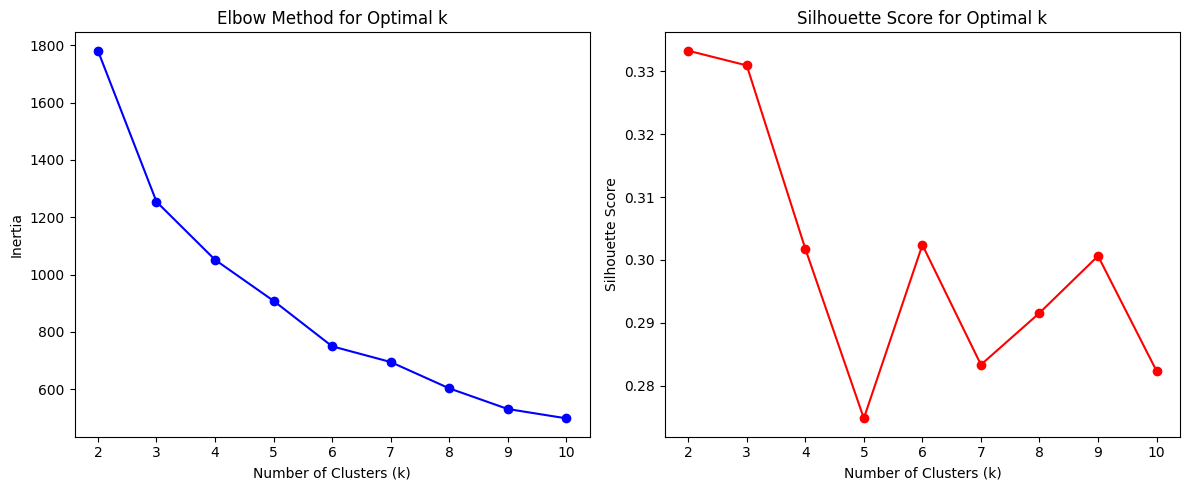

Cluster Counts:
Takeons_Cluster
5    129
3    110
4     75
0     64
1     44
2     38
Name: count, dtype: int64


In [37]:
inertia = []
silhouette_scores = []
K = range(2, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(takeon_features_scaled)
    inertia.append(kmeans.inertia_)
    if k > 1:
        score = silhouette_score(takeon_features_scaled, kmeans.labels_)
        silhouette_scores.append(score)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(K, inertia, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')

plt.subplot(1, 2, 2)
plt.plot(range(2, 11), silhouette_scores, 'ro-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Optimal k')
plt.tight_layout()
plt.show()

optimal_k = 6
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
df_takeons['Takeons_Cluster'] = kmeans.fit_predict(takeon_features_scaled)

print("Cluster Counts:")
print(df_takeons['Takeons_Cluster'].value_counts())

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


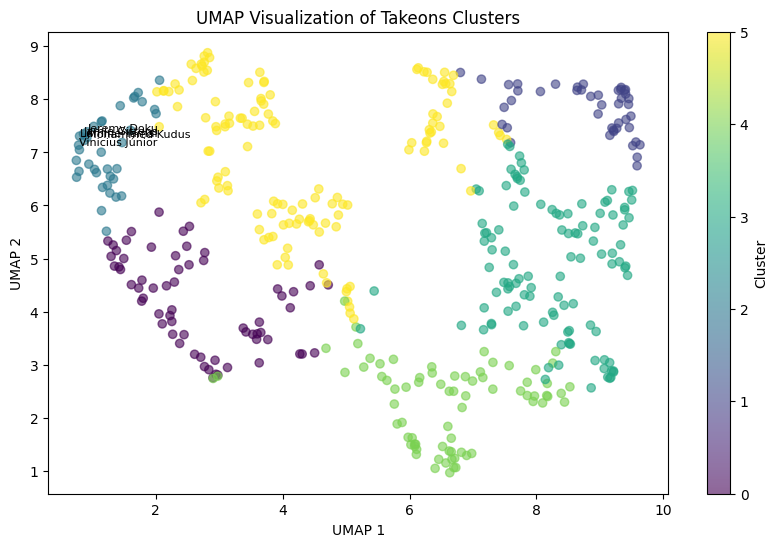

In [38]:
reducer = umap.UMAP(n_components=2, random_state=42)
takeon_umap = reducer.fit_transform(takeon_features_scaled)

df_umap = pd.DataFrame(takeon_umap, columns=['UMAP1', 'UMAP2'])
df_umap['Cluster'] = df_takeons['Takeons_Cluster']
df_umap['Player'] = df_takeons['Player']

plt.figure(figsize=(10, 6))
scatter = plt.scatter(df_umap['UMAP1'], df_umap['UMAP2'], c=df_umap['Cluster'], cmap='viridis', alpha=0.6)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.title('UMAP Visualization of Takeons Clusters')

top_players = df_takeons.sort_values('Succ_per90', ascending=False).head(5)['Player']
for i, player in enumerate(df_umap['Player']):
    if player in top_players.values:
        plt.annotate(player, (df_umap['UMAP1'][i], df_umap['UMAP2'][i]), fontsize=8)

plt.show()

In [39]:
cluster_summary = df_takeons.groupby('Takeons_Cluster')[['Att_per90', 'Succ_per90', 'Tkld_per90', 'Succ_Rate',
                                                       'Tkld_Rate', 'Risk_Index']].mean()
print("Cluster Summary (Average Stats per 90):")
print(cluster_summary)

for cluster in range(6):
    avg_att = cluster_summary.loc[cluster, 'Att_per90']
    avg_succ = cluster_summary.loc[cluster, 'Succ_per90']
    avg_tkld = cluster_summary.loc[cluster, 'Tkld_per90']
    avg_succ_rate = cluster_summary.loc[cluster, 'Succ_Rate']
    avg_tkld_rate = cluster_summary.loc[cluster, 'Tkld_Rate']
    avg_risk = cluster_summary.loc[cluster, 'Risk_Index']
    print(f"Cluster {cluster}: Avg Att per 90 = {avg_att:.2f}, Avg Succ per 90 = {avg_succ:.2f}, "
          f"Avg Tkld per 90 = {avg_tkld:.2f}, Avg Succ Rate = {avg_succ_rate:.3f}, "
          f"Avg Tkld Rate = {avg_tkld_rate:.3f}, Avg Risk Index = {avg_risk:.3f}")
    if avg_succ > 2.5 and avg_risk < 1.0:
        print("   Suggested Label: 'Elite Dribbler' (High success, low risk)")
    elif avg_succ_rate > 0.50 and avg_att < 2.5:
        print("   Suggested Label: 'Skilled Take-On Specialist' (High success rate, low attempts)")
    elif avg_tkld > 2.0 and avg_risk > 0.9:
        print("   Suggested Label: 'Risky Dribbler' (High tackles, high risk)")
    elif avg_succ < 0.7 and avg_succ_rate < 0.45:
        print("   Suggested Label: 'Ineffective Dribbler' (Low success, low success rate)")
    else:
        print("   Suggested Label: 'Balanced Dribbler' (Moderate take-on stats)")

df_takeons.to_csv('/content/takeons_with_clusters.csv', index=False)
print("\nSaved Takeons dataset with clusters to '/content/takeons_with_clusters.csv'")

Cluster Summary (Average Stats per 90):
                 Att_per90  Succ_per90  Tkld_per90  Succ_Rate  Tkld_Rate  \
Takeons_Cluster                                                            
0                 3.727291    1.214729    2.187737   0.318462   0.581949   
1                 1.841195    1.014603    0.644195   0.535239   0.337722   
2                 6.150288    2.714081    2.905141   0.434537   0.474803   
3                 1.535206    0.642954    0.751312   0.400134   0.476756   
4                 1.656100    0.490087    1.013380   0.277339   0.599901   
5                 3.625404    1.626399    1.663440   0.441389   0.455005   

                 Risk_Index  
Takeons_Cluster              
0                  0.988691  
1                  0.308814  
2                  0.796358  
3                  0.446558  
4                  0.670064  
5                  0.636166  
Cluster 0: Avg Att per 90 = 3.73, Avg Succ per 90 = 1.21, Avg Tkld per 90 = 2.19, Avg Succ Rate = 0.318, Avg Tk

In [40]:
df_defence = pd.read_csv('/content/defensive_cleaned.csv')

df_defence['Tkl_per90'] = df_defence['Tkl'] / (df_defence['Total_Minutes'] / 90)
df_defence['TklW_per90'] = df_defence['TklW'] / (df_defence['Total_Minutes'] / 90)
df_defence['Def3rd_per90'] = df_defence['Def 3rd'] / (df_defence['Total_Minutes'] / 90)
df_defence['Mid3rd_per90'] = df_defence['Mid 3rd'] / (df_defence['Total_Minutes'] / 90)
df_defence['Att3rd_per90'] = df_defence['Att 3rd'] / (df_defence['Total_Minutes'] / 90)
df_defence['Blocks_per90'] = df_defence['Blocks'] / (df_defence['Total_Minutes'] / 90)
df_defence['Sh_per90'] = df_defence['Sh'] / (df_defence['Total_Minutes'] / 90)
df_defence['Pass_per90'] = df_defence['Pass'] / (df_defence['Total_Minutes'] / 90)
df_defence['Int_per90'] = df_defence['Int'] / (df_defence['Total_Minutes'] / 90)
df_defence['TklInt_per90'] = df_defence['Tkl+Int'] / (df_defence['Total_Minutes'] / 90)
df_defence['Clr_per90'] = df_defence['Clr'] / (df_defence['Total_Minutes'] / 90)
df_defence['Err_per90'] = df_defence['Err'] / (df_defence['Total_Minutes'] / 90)
df_defence['TklEff'] = df_defence['TklW'] / (df_defence['Tkl'] + 1)
df_defence['Def3rd_Ratio'] = df_defence['Def 3rd'] / (df_defence['Tkl'] + 1)
df_defence['Att3rd_Ratio'] = df_defence['Att 3rd'] / (df_defence['Tkl'] + 1)
df_defence['BlockRatio'] = df_defence['Blocks'] / (df_defence['Tkl'] + df_defence['Int'] + 1)
df_defence['ErrRate'] = df_defence['Err'] / (df_defence['Tkl'] + df_defence['Int'] + df_defence['Clr'] + 1)
df_defence['DefImpact'] = (df_defence['TklW_per90'] + df_defence['Int_per90'] + df_defence['Clr_per90']) / (df_defence['Err_per90'] + 1)

defence_features = df_defence[['Tkl_per90', 'TklW_per90', 'Def3rd_per90', 'Mid3rd_per90', 'Att3rd_per90',
                               'Blocks_per90', 'Sh_per90', 'Pass_per90', 'Int_per90', 'TklInt_per90',
                               'Clr_per90', 'Err_per90', 'TklEff', 'Def3rd_Ratio', 'Att3rd_Ratio',
                               'BlockRatio', 'ErrRate', 'DefImpact']]

scaler = StandardScaler()
defence_features_scaled = scaler.fit_transform(defence_features)

print("Prepared Features (first 5 rows):")
print(pd.DataFrame(defence_features_scaled, columns=['Tkl_per90', 'TklW_per90', 'Def3rd_per90', 'Mid3rd_per90',
                                                    'Att3rd_per90', 'Blocks_per90', 'Sh_per90', 'Pass_per90',
                                                    'Int_per90', 'TklInt_per90', 'Clr_per90', 'Err_per90',
                                                    'TklEff', 'Def3rd_Ratio', 'Att3rd_Ratio', 'BlockRatio',
                                                    'ErrRate', 'DefImpact']).head())

Prepared Features (first 5 rows):
   Tkl_per90  TklW_per90  Def3rd_per90  Mid3rd_per90  Att3rd_per90  \
0   3.248077    2.759403      2.520351      3.540759      1.316130   
1   4.164724    3.243849      4.219904      3.613035      1.390744   
2   2.067576    1.534293      1.229226      1.290715      3.453864   
3   1.819343    1.518568      0.351602      2.568485      1.834507   
4   1.960450    1.628678      1.560313      2.070809      0.839031   

   Blocks_per90  Sh_per90  Pass_per90  Int_per90  TklInt_per90  Clr_per90  \
0      4.034770  2.885676    3.569927   2.202934      3.197712   1.670012   
1      2.468779  4.505283    1.363096   3.149470      4.208846   2.696661   
2      1.101435 -0.031233    1.220047   1.443165      2.049195   0.150365   
3      1.418437  0.727304    1.341104   2.416248      2.186768   0.189194   
4      0.722642  0.549027    0.629737   0.911816      1.790239   0.889948   

   Err_per90    TklEff  Def3rd_Ratio  Att3rd_Ratio  BlockRatio   ErrRate  \
0   0.

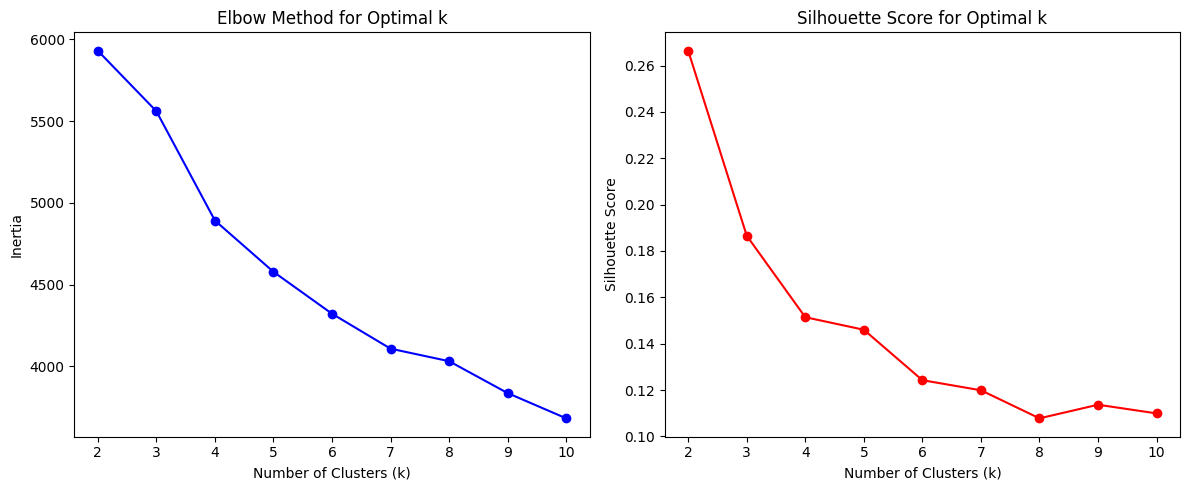

Cluster Counts:
Defence_Cluster
3    179
1    132
4     65
2     58
0     26
Name: count, dtype: int64


In [41]:
inertia = []
silhouette_scores = []
K = range(2, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(defence_features_scaled)
    inertia.append(kmeans.inertia_)
    if k > 1:
        score = silhouette_score(defence_features_scaled, kmeans.labels_)
        silhouette_scores.append(score)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(K, inertia, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')

plt.subplot(1, 2, 2)
plt.plot(range(2, 11), silhouette_scores, 'ro-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Optimal k')
plt.tight_layout()
plt.show()

optimal_k = 5
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
df_defence['Defence_Cluster'] = kmeans.fit_predict(defence_features_scaled)

print("Cluster Counts:")
print(df_defence['Defence_Cluster'].value_counts())

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


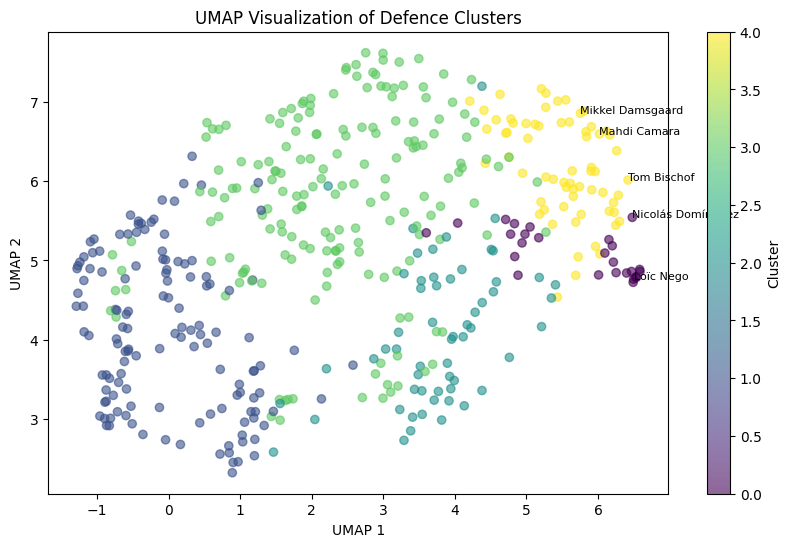

In [42]:
reducer = umap.UMAP(n_components=2, random_state=42)
defence_umap = reducer.fit_transform(defence_features_scaled)

df_umap = pd.DataFrame(defence_umap, columns=['UMAP1', 'UMAP2'])
df_umap['Cluster'] = df_defence['Defence_Cluster']
df_umap['Player'] = df_defence['Player']

plt.figure(figsize=(10, 6))
scatter = plt.scatter(df_umap['UMAP1'], df_umap['UMAP2'], c=df_umap['Cluster'], cmap='viridis', alpha=0.6)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.title('UMAP Visualization of Defence Clusters')

top_players = df_defence.sort_values('Tkl+Int', ascending=False).head(5)['Player']
for i, player in enumerate(df_umap['Player']):
    if player in top_players.values:
        plt.annotate(player, (df_umap['UMAP1'][i], df_umap['UMAP2'][i]), fontsize=8)

plt.show()

In [43]:
cluster_summary = df_defence.groupby('Defence_Cluster')[['Tkl_per90', 'TklW_per90', 'Def3rd_per90', 'Mid3rd_per90',
                                                       'Att3rd_per90', 'Blocks_per90', 'Sh_per90', 'Pass_per90',
                                                       'Int_per90', 'TklInt_per90', 'Clr_per90', 'Err_per90',
                                                       'TklEff', 'Def3rd_Ratio', 'Att3rd_Ratio', 'BlockRatio',
                                                       'ErrRate', 'DefImpact']].mean()
print("Cluster Summary (Average Stats per 90):")
print(cluster_summary)

for cluster in range(5):
    avg_tkl = cluster_summary.loc[cluster, 'Tkl_per90']
    avg_tklw = cluster_summary.loc[cluster, 'TklW_per90']
    avg_def3rd = cluster_summary.loc[cluster, 'Def3rd_per90']
    avg_mid3rd = cluster_summary.loc[cluster, 'Mid3rd_per90']
    avg_att3rd = cluster_summary.loc[cluster, 'Att3rd_per90']
    avg_blocks = cluster_summary.loc[cluster, 'Blocks_per90']
    avg_int = cluster_summary.loc[cluster, 'Int_per90']
    avg_clr = cluster_summary.loc[cluster, 'Clr_per90']
    avg_err = cluster_summary.loc[cluster, 'Err_per90']
    avg_tkleff = cluster_summary.loc[cluster, 'TklEff']
    avg_def3rd_ratio = cluster_summary.loc[cluster, 'Def3rd_Ratio']
    avg_att3rd_ratio = cluster_summary.loc[cluster, 'Att3rd_Ratio']
    avg_defimpact = cluster_summary.loc[cluster, 'DefImpact']
    print(f"Cluster {cluster}: Avg Tkl per 90 = {avg_tkl:.2f}, Avg TklW per 90 = {avg_tklw:.2f}, "
          f"Avg Def3rd per 90 = {avg_def3rd:.2f}, Avg Mid3rd per 90 = {avg_mid3rd:.2f}, "
          f"Avg Att3rd per 90 = {avg_att3rd:.2f}, Avg Blocks per 90 = {avg_blocks:.2f}, "
          f"Avg Int per 90 = {avg_int:.2f}, Avg Clr per 90 = {avg_clr:.2f}, Avg Err per 90 = {avg_err:.2f}, "
          f"Avg TklEff = {avg_tkleff:.3f}, Avg Def3rd Ratio = {avg_def3rd_ratio:.3f}, "
          f"Avg Att3rd Ratio = {avg_att3rd_ratio:.3f}, Avg DefImpact = {avg_defimpact:.3f}")
    if avg_tkl > 2.0 and avg_defimpact > 2.5 and avg_err < 0.05:
        print("   Suggested Label: 'Pressing Specialist' (High tackles, strong impact, low errors)")
    elif avg_clr > 1.5 and avg_defimpact > 3.0:
        print("   Suggested Label: 'Clearance Defender' (High clearances, strong impact)")
    elif avg_err > 0.08 and avg_tkl > 1.0:
        print("   Suggested Label: 'Inconsistent Defender' (High errors, moderate tackles)")
    elif avg_tkl > 1.0 and avg_err < 0.02:
        print("   Suggested Label: 'Baseline Defender' (Moderate tackles, low errors)")
    else:
        print("   Suggested Label: 'Minimal Defender' (Low defensive involvement)")

df_defence.to_csv('/content/defence_with_clusters.csv', index=False)
print("\nSaved Defence dataset with clusters to '/content/defence_with_clusters.csv'")

Cluster Summary (Average Stats per 90):
                 Tkl_per90  TklW_per90  Def3rd_per90  Mid3rd_per90  \
Defence_Cluster                                                      
0                 1.864275    1.146434      0.990907      0.632807   
1                 0.522963    0.304158      0.111533      0.233223   
2                 1.401143    0.847256      0.537129      0.598236   
3                 1.182229    0.714988      0.382416      0.487048   
4                 2.240419    1.362079      0.845987      0.958257   

                 Att3rd_per90  Blocks_per90  Sh_per90  Pass_per90  Int_per90  \
Defence_Cluster                                                                
0                    0.240561      1.180651  0.285990    0.894661   0.874426   
1                    0.178207      0.529751  0.076686    0.453065   0.194706   
2                    0.265777      0.904819  0.114134    0.790685   0.432568   
3                    0.312764      0.808910  0.067723    0.741187   0

In [44]:
df_aerial = pd.read_csv('/content/aerial_cleaned.csv')

df_aerial['Won_per90'] = df_aerial['Won'] / (df_aerial['Total_Minutes'] / 90)
df_aerial['Lost_per90'] = df_aerial['Lost'] / (df_aerial['Total_Minutes'] / 90)
df_aerial['TotalAerials_per90'] = (df_aerial['Won'] + df_aerial['Lost']) / (df_aerial['Total_Minutes'] / 90)
df_aerial['AerialEff'] = df_aerial['Won'] / (df_aerial['Won'] + df_aerial['Lost'] + 1)
df_aerial['AerialImpact'] = df_aerial['Won_per90'] / (df_aerial['Lost_per90'] + 1)

aerial_features = df_aerial[['Won_per90', 'Lost_per90', 'TotalAerials_per90', 'AerialEff', 'AerialImpact']]

scaler = StandardScaler()
aerial_features_scaled = scaler.fit_transform(aerial_features)

print("Prepared Features (first 5 rows):")
print(pd.DataFrame(aerial_features_scaled, columns=['Won_per90', 'Lost_per90', 'TotalAerials_per90',
                                                    'AerialEff', 'AerialImpact']).head())

Prepared Features (first 5 rows):
   Won_per90  Lost_per90  TotalAerials_per90  AerialEff  AerialImpact
0   1.034357   -0.717155            0.196255   3.001201      3.926795
1  -0.592079   -1.241509           -0.952395   2.338279      0.047681
2   6.474308    1.697296            4.374093   2.736602      6.199048
3   1.956325    0.119601            1.121731   2.356196      3.571585
4   0.911566   -0.420615            0.280457   2.285245      2.742114


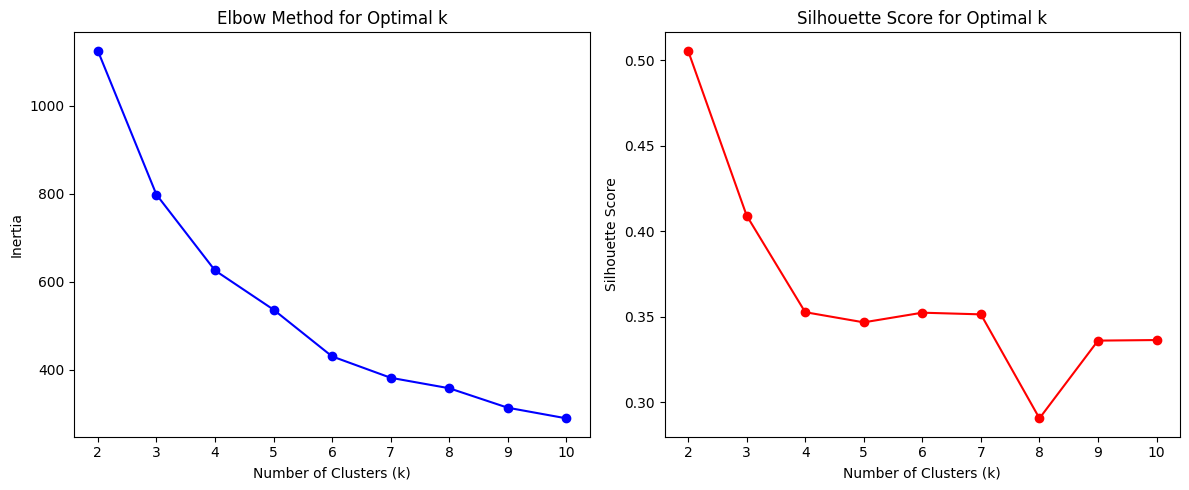

Cluster Counts:
Aerial_Cluster
3    184
0    146
1    103
2     27
Name: count, dtype: int64


In [45]:
inertia = []
silhouette_scores = []
K = range(2, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(aerial_features_scaled)
    inertia.append(kmeans.inertia_)
    if k > 1:
        score = silhouette_score(aerial_features_scaled, kmeans.labels_)
        silhouette_scores.append(score)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(K, inertia, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')

plt.subplot(1, 2, 2)
plt.plot(range(2, 11), silhouette_scores, 'ro-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Optimal k')
plt.tight_layout()
plt.show()

optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
df_aerial['Aerial_Cluster'] = kmeans.fit_predict(aerial_features_scaled)

print("Cluster Counts:")
print(df_aerial['Aerial_Cluster'].value_counts())

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


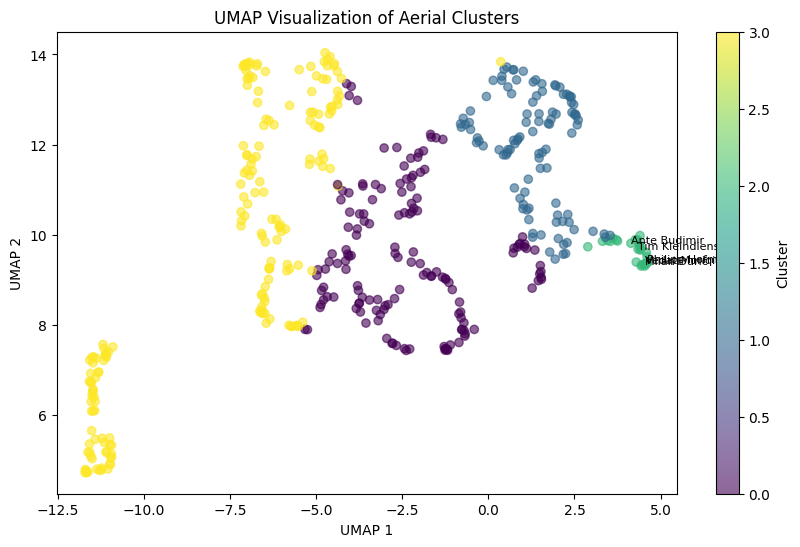

In [46]:
reducer = umap.UMAP(n_components=2, random_state=42)
aerial_umap = reducer.fit_transform(aerial_features_scaled)

df_umap = pd.DataFrame(aerial_umap, columns=['UMAP1', 'UMAP2'])
df_umap['Cluster'] = df_aerial['Aerial_Cluster']
df_umap['Player'] = df_aerial['Player']

plt.figure(figsize=(10, 6))
scatter = plt.scatter(df_umap['UMAP1'], df_umap['UMAP2'], c=df_umap['Cluster'], cmap='viridis', alpha=0.6)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.title('UMAP Visualization of Aerial Clusters')

top_players = df_aerial.sort_values('Won', ascending=False).head(5)['Player']
for i, player in enumerate(df_umap['Player']):
    if player in top_players.values:
        plt.annotate(player, (df_umap['UMAP1'][i], df_umap['UMAP2'][i]), fontsize=8)

plt.show()

In [47]:
cluster_summary = df_aerial.groupby('Aerial_Cluster')[['Won_per90', 'Lost_per90', 'TotalAerials_per90',
                                                      'AerialEff', 'AerialImpact']].mean()
print("Cluster Summary (Average Stats per 90):")
print(cluster_summary)

for cluster in range(4):
    avg_won = cluster_summary.loc[cluster, 'Won_per90']
    avg_lost = cluster_summary.loc[cluster, 'Lost_per90']
    avg_total = cluster_summary.loc[cluster, 'TotalAerials_per90']
    avg_eff = cluster_summary.loc[cluster, 'AerialEff']
    avg_impact = cluster_summary.loc[cluster, 'AerialImpact']
    print(f"Cluster {cluster}: Avg Won per 90 = {avg_won:.2f}, Avg Lost per 90 = {avg_lost:.2f}, "
          f"Avg Total Aerials per 90 = {avg_total:.2f}, Avg Aerial Eff = {avg_eff:.3f}, "
          f"Avg Aerial Impact = {avg_impact:.3f}")
    if avg_won > 4.0 and avg_eff > 0.50:
        print("   Suggested Label: 'Aerial Dominator' (High wins, high efficiency)")
    elif avg_total > 3.0 and avg_eff > 0.40:
        print("   Suggested Label: 'Aerial Contender' (Frequent duels, decent efficiency)")
    elif avg_won < 0.5 and avg_eff < 0.30:
        print("   Suggested Label: 'Aerial Weakling' (Low wins, low efficiency)")
    else:
        print("   Suggested Label: 'Minimal Aerial Player' (Low aerial involvement)")

df_aerial.to_csv('/content/aerial_with_clusters.csv', index=False)
print("\nSaved Aerial dataset with clusters to '/content/aerial_with_clusters.csv'")

Cluster Summary (Average Stats per 90):
                Won_per90  Lost_per90  TotalAerials_per90  AerialEff  \
Aerial_Cluster                                                         
0                0.907621    1.087640            1.995261   0.447592   
1                2.268643    3.048489            5.317132   0.427114   
2                5.171502    4.163353            9.334854   0.549631   
3                0.413113    1.100304            1.513417   0.256930   

                AerialImpact  
Aerial_Cluster                
0                   0.424440  
1                   0.582394  
2                   1.021897  
3                   0.184964  
Cluster 0: Avg Won per 90 = 0.91, Avg Lost per 90 = 1.09, Avg Total Aerials per 90 = 2.00, Avg Aerial Eff = 0.448, Avg Aerial Impact = 0.424
   Suggested Label: 'Minimal Aerial Player' (Low aerial involvement)
Cluster 1: Avg Won per 90 = 2.27, Avg Lost per 90 = 3.05, Avg Total Aerials per 90 = 5.32, Avg Aerial Eff = 0.427, Avg Aerial Impac

# Finding Similar Players

In [48]:
datasets = {
    'Goals': '/content/goals_with_clusters.csv',
    'xG': '/content/xg_with_clusters.csv',
    'Shooting': '/content/shooting_with_clusters.csv',
    'Passing': '/content/passing_with_clusters.csv',
    'SCA': '/content/sca_with_clusters.csv',
    'GCA': '/content/gca_with_clusters.csv',
    'Carries': '/content/carries_with_clusters.csv',
    'Touches': '/content/touches_with_clusters.csv',
    'Takeons': '/content/takeons_with_clusters.csv',
    'Defence': '/content/defence_with_clusters.csv',
    'Aerial': '/content/aerial_with_clusters.csv'
}

dfs = []
for category, path in datasets.items():
    df = pd.read_csv(path)
    cluster_col = f'{category}_Cluster'
    df = df[['Player_ID', cluster_col]]
    dfs.append(df)

df_merged = dfs[0]
for df in dfs[1:]:
    df_merged = df_merged.merge(df, on='Player_ID', how='inner')

print("Merged DataFrame Shape:", df_merged.shape)
print("Merged DataFrame (first 5 rows):")
print(df_merged.head())

Merged DataFrame Shape: (460, 12)
Merged DataFrame (first 5 rows):
  Player_ID  Goals_Cluster  xG_Cluster  Shooting_Cluster  Passing_Cluster  \
0  42fd9c7f              4           3                 2                0   
1  e342ad68              2           3                 2                2   
2  8d78e732              4           2                 2                3   
3  21a66f6a              2           3                 2                0   
4  e7695e6c              4           3                 2                3   

   SCA_Cluster  GCA_Cluster  Carries_Cluster  Touches_Cluster  \
0            0            2                2                4   
1            1            2                2                4   
2            4            1                3                0   
3            0            2                3                0   
4            5            1                3                0   

   Takeons_Cluster  Defence_Cluster  Aerial_Cluster  
0                2       

In [49]:
cluster_labels = df_merged.drop(columns=['Player_ID']).values

num_players = len(df_merged)
co_occurrence_matrix = np.zeros((num_players, num_players), dtype=int)

for i in range(num_players):
    for j in range(i + 1, num_players):
        matches = np.sum(cluster_labels[i] == cluster_labels[j])
        co_occurrence_matrix[i, j] = matches
        co_occurrence_matrix[j, i] = matches

player_ids = df_merged['Player_ID'].values
co_occurrence_df = pd.DataFrame(co_occurrence_matrix, index=player_ids, columns=player_ids)

print("Co-Occurrence Matrix Shape:", co_occurrence_df.shape)
print("Co-Occurrence Matrix (first 5 rows and columns):")
print(co_occurrence_df.iloc[:5, :5])

Co-Occurrence Matrix Shape: (460, 460)
Co-Occurrence Matrix (first 5 rows and columns):
          42fd9c7f  e342ad68  8d78e732  21a66f6a  e7695e6c
42fd9c7f         0         7         3         6         4
e342ad68         7         0         2         5         3
8d78e732         3         2         0         5         7
21a66f6a         6         5         5         0         6
e7695e6c         4         3         7         6         0


In [50]:
threshold = 8
similar_pairs = []

for i in range(num_players):
    for j in range(i + 1, num_players):
        if co_occurrence_matrix[i, j] >= threshold:
            player1_id = player_ids[i]
            player2_id = player_ids[j]
            df_aerial = pd.read_csv('/content/aerial_with_clusters.csv')
            player1_name = df_aerial[df_aerial['Player_ID'] == player1_id]['Player'].values[0]
            player2_name = df_aerial[df_aerial['Player_ID'] == player2_id]['Player'].values[0]
            similar_pairs.append({
                'Player1': player1_name,
                'Player2': player2_name,
                'Player1_ID': player1_id,
                'Player2_ID': player2_id,
                'Co-Occurrence': co_occurrence_matrix[i, j]
            })

similar_pairs_df = pd.DataFrame(similar_pairs)
if not similar_pairs_df.empty:
    similar_pairs_df = similar_pairs_df.sort_values(by='Co-Occurrence', ascending=False)
    print("Most Similar Player Pairs (Co-Occurrence >= 8):")
    print(similar_pairs_df)
else:
    print(f"No player pairs found with co-occurrence >= {threshold}. Try lowering the threshold.")

co_occurrence_df.to_csv('/content/co_occurrence_matrix.csv')
similar_pairs_df.to_csv('/content/similar_player_pairs.csv', index=False)
print("\nSaved co-occurrence matrix to '/content/co_occurrence_matrix.csv'")
print("Saved similar player pairs to '/content/similar_player_pairs.csv'")

Most Similar Player Pairs (Co-Occurrence >= 8):
                    Player1          Player2 Player1_ID Player2_ID  \
926   Dominic Calvert-Lewin  Bertuğ Yıldırım   59e6e5bf   7410d325   
133    Jean-Philippe Mateta     Artem Dovbyk   50e6dc35   5b847bb0   
285              Leroy Sané   Kingsley Coman   2b114be3   042e8a49   
1007          Patrick Dorgu    Pep Chavarría   e6536124   63c5e56b   
152    Jean-Philippe Mateta    Borja Mayoral   50e6dc35   64e8ed6d   
...                     ...              ...        ...        ...   
8             Mateo Retegui       Chris Wood   e7695e6c   4e9a0555   
7        Robert Lewandowski    Gonçalo Ramos   8d78e732   f63cda26   
6        Robert Lewandowski       Moise Kean   8d78e732   3d50bcdb   
2             Mohamed Salah  Mason Greenwood   e342ad68   58eee997   
1             Kylian Mbappé  Vinicius Júnior   42fd9c7f   7111d552   

      Co-Occurrence  
926              11  
133              11  
285              11  
1007             10  
1

In [51]:
import pandas as pd

def find_similar_players(player_name, min_co_occurrence=7, top_n=5):

    co_occurrence_df = pd.read_csv('/content/co_occurrence_matrix.csv', index_col=0)

    df_aerial = pd.read_csv('/content/aerial_with_clusters.csv')

    player_row = df_aerial[df_aerial['Player'] == player_name]
    if player_row.empty:
        return f"Player '{player_name}' not found in the dataset."

    player_id = player_row['Player_ID'].values[0]

    if player_id not in co_occurrence_df.index:
        return f"Player ID '{player_id}' not found in the co-occurrence matrix."

    player_co_occurrences = co_occurrence_df.loc[player_id]

    similar_players = player_co_occurrences[player_co_occurrences >= min_co_occurrence]

    similar_players = similar_players[similar_players.index != player_id]

    if similar_players.empty:
        return f"No players found with co-occurrence >= {min_co_occurrence} for {player_name}."

    similar_players_df = pd.DataFrame({
        'Similar_Player_ID': similar_players.index,
        'Co-Occurrence': similar_players.values
    })

    similar_players_df = similar_players_df.merge(
        df_aerial[['Player_ID', 'Player']],
        left_on='Similar_Player_ID',
        right_on='Player_ID',
        how='left'
    )

    similar_players_df = similar_players_df[['Player', 'Co-Occurrence']]
    similar_players_df.columns = ['Similar Player', 'Co-Occurrence']

    similar_players_df = similar_players_df.sort_values(by='Co-Occurrence', ascending=False).head(top_n)

    print(f"Most similar players to {player_name}:")
    return similar_players_df

In [57]:
result = find_similar_players("Serhou Guirassy")
print(result)

Most similar players to Serhou Guirassy:
      Similar Player  Co-Occurrence
4  Alexander Sørloth              9
3       Ante Budimir              8
1     Erling Haaland              8
7     Jonathan David              8
8  Ermedin Demirović              8
